1. ##### Importação das Bibliotecas e Conjunto de Dados

Importando as ferramentas essenciais para carregar, manipular, analisar e visualizar os dados:

In [7]:
#análise
'''Importa a biblioteca Pandas, fundamental para manipulação e análise de dados em Python.
Ela é usada para criar e trabalhar com estruturas de dados tabulares chamadas DataFrames.
pd é o apelido (alias) padrão para o Pandas.'''

import pandas as pd 

''' Importa a biblioteca NumPy, que é a base para computação numérica em Python.
Ela fornece suporte para arrays e matrizes multidimensionais, além de uma vasta coleção de funções matemáticas. '''

import numpy as np

#Biblioteca para manipular bancos de dados SQL
import pyodbc
from sqlalchemy import create_engine

In [8]:
#visualização
'''Importa o submódulo pyplot da biblioteca Matplotlib, que é a biblioteca
mais fundamental para criar visualizações estáticas, animadas e interativas em Python.'''

import matplotlib.pyplot as plt

''' Importa a biblioteca Seaborn, que é construída sobre o Matplotlib.
Ela oferece uma interface de alto nível para desenhar gráficos estatísticos atraentes e informativos.'''

import seaborn as sns

'''Esta função do Seaborn aplica o tema padrão da biblioteca a todos os gráficos gerados pelo Matplotlib.
Isso melhora a estética geral das visualizações, deixando-as mais modernas e legíveis.'''
sns.set_theme()


In [9]:
#dividindo a base de dados

'''Importa a função train_test_split da biblioteca Scikit-learn.
Esta função é crucial para dividir o conjunto de dados em subconjuntos de treino e teste,
uma prática fundamental em machine learning para avaliar o desempenho do modelo em dados não vistos.'''

from sklearn.model_selection import train_test_split

#tratando dados categóricos e numéricos

'''Importa a classe MinMaxScaler do Scikit-learn, usada para normalizar features numéricas,
escalando-as para um intervalo específico (geralmente entre 0 e 1).'''

from sklearn.preprocessing import MinMaxScaler

#classificadores

'''Importa o classificador K-Nearest Neighbors (KNN), um algoritmo baseado em instância.'''

from sklearn.neighbors import KNeighborsClassifier

'''Importa o classificador Random Forest, um modelo de ensemble que utiliza múltiplas árvores de decisão.'''

from sklearn.ensemble import RandomForestClassifier

'''Importa o Multi-layer Perceptron (MLP), um modelo de rede neural artificial.'''

from sklearn.neural_network import MLPClassifier

''' Importa o LabelEncoder, uma ferramenta para converter variáveis categóricas textuais em números inteiros.'''

from sklearn.preprocessing import LabelEncoder

'''Importa o classificador de Regressão Logística.'''

from sklearn.linear_model import LogisticRegression

'''Importa várias métricas de avaliação de modelos de classificação:
* accuracy_score: Calcula a acurácia.
* balanced_accuracy_score: Acurácia para dados desbalanceados.
* precision_score: Calcula a precisão.
* recall_score: Calcula a revocação (sensibilidade).
* f1_score: Calcula o F1-Score, a média harmônica de precisão e recall.
* roc_auc_score: Calcula a área sob a curva ROC.'''

from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

'''Importa a classe SMOTE (Synthetic Minority Over-sampling Technique) da biblioteca imbalanced-learn.
É uma técnica popular para lidar com dados desbalanceados, criando novas amostras sintéticas da classe minoritária.'''

from imblearn.over_sampling import SMOTE


#metricas de avaliação de qualidade - SMOTE -

'''Importa funções para:
* classification_report: Gerar um relatório detalhado com as principais métricas.
* ConfusionMatrixDisplay: Visualizar uma matriz de confusão.
* confusion_matrix: Calcular a matriz de confusão.'''

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

''' Importa o GridSearchCV, uma ferramenta para otimização de hiperparâmetros
que testa exaustivamente uma "grade" de combinações de parâmetros.'''

from sklearn.model_selection import GridSearchCV



#removendo aviso de erro para o BayesSearchCV

''' Importa o módulo warnings do Python para controlar a exibição de avisos.'''

import warnings

'''Configura o módulo de avisos para ignorar uma mensagem específica 
que pode surgir durante a otimização de hiperparâmetros, quando o mesmo ponto é avaliado mais de uma vez.'''

warnings.filterwarnings('ignore', message='The objective has been evaluated at this point before.')



# Inspecionando os modelos

''' Importa a função permutation_importance, um método para avaliar a importância de cada feature para um modelo já treinado.'''
from sklearn.inspection import permutation_importance

## COVERTENDO O ARQUIVO .CSV PARA SQL:

In [206]:
'''
# --- Passo 1: Ler o arquivo CSV original com Pandas ---
# IMPORTANTE: Altere o caminho abaixo para o local do seu arquivo.
caminho_csv = r'Datasets/BankChurners.csv'
df = pd.read_csv(caminho_csv)

print("Arquivo CSV carregado com sucesso.")

# --- Passo 2: Renomear as colunas no DataFrame para corresponder à tabela SQL ---
# Esta etapa é CRUCIAL para alinhar os nomes longos do CSV com os nomes curtos do SQL.
# VERIFIQUE se os nomes longos abaixo correspondem exatamente ao seu CSV.
df.rename(columns={
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1': 'Naive_Bayes_Classifier_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2': 'Naive_Bayes_Classifier_2'
}, inplace=True)

print("Colunas do DataFrame renomeadas para corresponder ao SQL.")

# --- Passo 3: Conectar ao Banco e Inserir os Dados ---
# IMPORTANTE: Altere o NOME_DO_SEU_SERVIDOR
conexao_str = (
    r"Driver={ODBC Driver 17 for SQL Server};"
    r"Server=JHON\SQLEXPRESS;" 
    r"Database=Banco_Churn;"
    r"Trusted_Connection=yes;"
)

# Bloco de código para executar a inserção de forma segura
try:
    conexao_sql = pyodbc.connect(conexao_str)
    cursor = conexao_sql.cursor()
    print("Conexão com SQL Server bem-sucedida.")

    # (Opcional, mas recomendado) Limpa a tabela antes de inserir para evitar duplicatas.
    cursor.execute("TRUNCATE TABLE dbo.BankChurners")
    
    # Loop para inserir cada linha do DataFrame na tabela SQL
    for index, row in df.iterrows():
        # A ordem das colunas no INSERT deve ser a mesma da sua tabela
        cursor.execute("""
            INSERT INTO dbo.BankChurners (
                CLIENTNUM, Attrition_Flag, Customer_Age, Gender, Dependent_count,
                Education_Level, Marital_Status, Income_Category, Card_Category,
                Months_on_book, Total_Relationship_Count, Months_Inactive_12_mon,
                Contacts_Count_12_mon, Credit_Limit, Total_Revolving_Bal,
                Avg_Open_To_Buy, Total_Amt_Chng_Q4_Q1, Total_Trans_Amt,
                Total_Trans_Ct, Total_Ct_Chng_Q4_Q1, Avg_Utilization_Ratio,
                Naive_Bayes_Classifier_1, Naive_Bayes_Classifier_2
            ) VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)""",
            *row.values 
        )
    
    conexao_sql.commit()
    print("Dados inseridos com sucesso no banco de dados!")

except Exception as e:
    print(f"Ocorreu um erro durante a migração: {e}")

finally:
    if 'cursor' in locals():
        cursor.close()
    if 'conexao_sql' in locals():
        conexao_sql.close()
    print("Conexão com o banco de dados fechada.")'''

<>:23: SyntaxWarning: invalid escape sequence '\S'
<>:23: SyntaxWarning: invalid escape sequence '\S'
C:\Users\jhona\AppData\Local\Temp\ipykernel_7928\2383227410.py:23: SyntaxWarning: invalid escape sequence '\S'
  r"Server=JHON\SQLEXPRESS;"


'\n# --- Passo 1: Ler o arquivo CSV original com Pandas ---\n# IMPORTANTE: Altere o caminho abaixo para o local do seu arquivo.\ncaminho_csv = r\'Datasets/BankChurners.csv\'\ndf = pd.read_csv(caminho_csv)\n\nprint("Arquivo CSV carregado com sucesso.")\n\n# --- Passo 2: Renomear as colunas no DataFrame para corresponder à tabela SQL ---\n# Esta etapa é CRUCIAL para alinhar os nomes longos do CSV com os nomes curtos do SQL.\n# VERIFIQUE se os nomes longos abaixo correspondem exatamente ao seu CSV.\ndf.rename(columns={\n    \'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1\': \'Naive_Bayes_Classifier_1\',\n    \'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2\': \'Naive_Bayes_Classifier_2\'\n}, inplace=True)\n\nprint("Colunas do DataFrame renomeadas para corresponder ao SQL.")\n\n# --- Passo 3: Conectar ao Banco e Inserir os 

## CARREGANDO O BANCO DE DADOS SQL PARA INÍCIO DO TRATAMENTO DOS DADOS:

In [10]:
# --- 1. Informações de Conexão ---
#Preferi atribuir o nome do servidor a uma variável pois fica mais fácil de visualizar e modificar sem mudar nada sem querer na URI
nome_servidor = 'JHON\SQLEXPRESS' 
nome_banco_dados = 'Banco_Churn'

# Criando a string de conexão para o SQLAlchemy
string_conexao = f"mssql+pyodbc://{nome_servidor}/{nome_banco_dados}?driver=ODBC+Driver+17+for+SQL+Server"

# --- 2. Carregando os Dados ---
try:
    engine = create_engine(string_conexao)
    query = "SELECT * FROM dbo.BankChurners" 
    
    # Usa a função read_sql para executar a query e carregar o resultado em um DataFrame
    df = pd.read_sql(query, engine)
    
    print("Dados carregados com sucesso do SQL Server!")
    
    print("Shape do DataFrame:", df.shape)

except Exception as e:
    print(f"Ocorreu um erro ao conectar ou carregar os dados: {e}")


Dados carregados com sucesso do SQL Server!
Shape do DataFrame: (10127, 23)


<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\jhona\AppData\Local\Temp\ipykernel_10528\1396297067.py:3: SyntaxWarning: invalid escape sequence '\S'
  nome_servidor = 'JHON\SQLEXPRESS'


###### Analisando os dados:

In [11]:
# Confirma o carregamento e visualizar o DataFrame
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_1,Naive_Bayes_Classifier_2
0,708082083,Existing Customer,45,F,3,High School,Married,Less than $40K,Blue,36,...,3544.0,1661,1883.0,0.831,15149,111,0.734,0.469,0.000305,0.999690
1,708083283,Attrited Customer,58,M,0,Unknown,Single,$40K - $60K,Blue,45,...,3421.0,2517,904.0,0.992,992,21,0.400,0.736,0.988690,0.011310
2,708084558,Attrited Customer,46,M,3,Doctorate,Divorced,$80K - $120K,Blue,38,...,8258.0,1771,6487.0,0.000,1447,23,0.000,0.214,0.997800,0.002196
3,708085458,Existing Customer,34,F,2,Uneducated,Single,Less than $40K,Blue,24,...,1438.3,0,1438.3,0.827,3940,82,0.952,0.000,0.000117,0.999880
4,708086958,Existing Customer,49,F,2,Uneducated,Married,Unknown,Blue,41,...,3128.0,749,2379.0,0.598,4369,59,0.735,0.239,0.000207,0.999790


In [12]:
#verificando os tipos de dados

'''Este é um método muito útil do Pandas. Ele imprime um resumo conciso do DataFrame, que inclui:
* O número total de entradas (linhas).
* O número de colunas.
* Para cada coluna: o nome, a contagem de valores não nulos e o tipo de dado (Dtype).
* A quantidade de memória utilizada pelo DataFrame.'''

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

##### 2. Tratamento dos Dados


In [13]:
#Renomeando Colunas

'''Cria um dicionário Python chamado traducao_colunas.
As chaves são os nomes originais das colunas em inglês, e os valores são os novos nomes em português.
Isso é feito para melhorar a legibilidade e compreensão dos dados.'''

traducao_colunas = {
    'CLIENTNUM': 'ID_Cliente',
    'Attrition_Flag': 'Status_Churn',
    'Customer_Age': 'Idade_Cliente',
    'Gender' : 'Genero',
    'Dependent_count': 'Num_Dependentes',
    'Education_Level': 'Escolaridade',
    'Marital_Status': 'Estado_Civil',
    'Income_Category': 'Faixa_Renda',
    'Card_Category': 'Categoria_Cartao',
    'Months_on_book': 'Meses_Como_Cliente',
    'Total_Relationship_Count': 'Cont_Total_Relacionamento',
    'Months_Inactive_12_mon': 'Meses_Inativo_12m',
    'Contacts_Count_12_mon': 'Cont_Contatos_12m',
    'Credit_Limit': 'Limite_Credito',
    'Total_Revolving_Bal': 'Saldo_Rotativo_Total',
    'Avg_Open_To_Buy': 'Media_Disponivel_Compra',
    'Total_Amt_Chng_Q4_Q1': 'Var_Total_Valor_Q4_Q1',
    'Total_Trans_Amt': 'Valor_Total_Transacoes',
    'Total_Trans_Ct': 'Cont_Total_Transacoes',
    'Total_Ct_Chng_Q4_Q1': 'Var_Total_Cont_Q4_Q1',
    'Avg_Utilization_Ratio': 'Taxa_Media_Utilizacao',
    'Naive_Bayes_Classifier_1': 'Classificador_Naive_Bayes_1',
    'Naive_Bayes_Classifier_2': 'Classificador_Naive_Bayes_2'
}



#Renomeando linhas

'''Cria um segundo dicionário, traducao_valores, para mapear e traduzir os valores categóricos de inglês para português em várias colunas.'''

traducao_valores = {
    #Valores da coluna 'Attrition_Flag'
    'Existing Customer' : 'Cliente Ativo',
    'Attrited Customer' : 'Cliente em Churn',
        #Valores da coluna 'Gender'
    'M' : 'Masculino',
    'F' : 'Feminino',
    #Valores da coluna 'Education_Level'
    'High School' : 'Ensino Medio',
    'Graduate' : 'Graduacao',
    'Uneducated' : 'Sem instrucao',
    'College' : 'Graduacao Incompleta',
    'Post-Graduate' : 'Pos-Graduacao',
    'Doctorate' : 'Doutorado',
    'Unknown' : 'Nao Informado',
    #Valores da coluna 'Marital_Status'
    'Married': 'Casado(a)',
    'Single': 'Solteiro(a)',
    'Divorced': 'Divorciado(a)',
    'Unknown': 'Nao Informado'    
}

#substituindo as colunas(traduzindo para melhor compreensão)

'''Utiliza o método .rename() para aplicar o dicionário traducao_colunas ao DataFrame df.
O resultado é um novo DataFrame com as colunas traduzidas, armazenado em df_colunas_reanomeadas.'''

df_colunas_reanomeadas = df.rename(columns=traducao_colunas)

#substituindo os valores das células(traduzindo para melhor compreensão)

'''Utiliza o método .replace() para buscar e substituir todos os valores no DataFrame 
que correspondem às chaves do dicionário traducao_valores pelos seus respectivos valores. 
O resultado é armazenado em df_valores_renomeados.'''

df_valores_renomeados = df_colunas_reanomeadas.replace(traducao_valores)





# Atribuindo o resultado final ao DataFrame Churn_df:

''' Atribui o DataFrame totalmente traduzido a uma nova variável Churn_df para uso posterior.'''

Churn_df = df_valores_renomeados

# --- Salvando o DataFrame tratado de volta no SQL Server ---

'''
Esta etapa substitui o salvamento em um arquivo estático (Excel/CSV).
Vamos carregar o DataFrame 'Churn_df', já limpo e tratado, para uma nova
tabela no SQL Server. Isso cria uma "fonte da verdade" para os dados tratados.
'''


nome_tabela_tratada = 'BankChurners_Tratado'

try:
    # Usamos o método .to_sql() do pandas para salvar o DataFrame
    Churn_df.to_sql(
        name=nome_tabela_tratada,  # Nome da nova tabela no SQL
        con=engine,               # A conexão com o banco de dados
        if_exists='replace',      # Se a tabela já existir, ela será substituída. Ótimo para reexecutar o notebook.
        index=False               # Não salva o índice do DataFrame como uma coluna na tabela
    )
    
    print(f"O DataFrame tratado foi salvo com sucesso na tabela '{nome_tabela_tratada}' no SQL Server!")

except Exception as e:
    print(f"Ocorreu um erro ao salvar a tabela no SQL: {e}")


O DataFrame tratado foi salvo com sucesso na tabela 'BankChurners_Tratado' no SQL Server!


In [14]:
#lendo as 5 primeiras linhas novamente para verificar alterações

'''Este método exibe as cinco primeiras linhas do DataFrame Churn_df.
O objetivo aqui é inspecionar visualmente os dados e confirmar que as traduções de colunas e valores da célula anterior foram aplicadas corretamente.'''
Churn_df.head()

,ID_Cliente,Status_Churn,Idade_Cliente,Genero,Num_Dependentes,Escolaridade,Estado_Civil,Faixa_Renda,Categoria_Cartao,Meses_Como_Cliente,...,Limite_Credito,Saldo_Rotativo_Total,Media_Disponivel_Compra,Var_Total_Valor_Q4_Q1,Valor_Total_Transacoes,Cont_Total_Transacoes,Var_Total_Cont_Q4_Q1,Taxa_Media_Utilizacao,Classificador_Naive_Bayes_1,Classificador_Naive_Bayes_2
0,708082083,Cliente Ativo,45,Feminino,3,Ensino Medio,Casado(a),Less than $40K,Blue,36,...,3544.0,1661,1883.0,0.831,15149,111,0.734,0.469,0.000305,0.999690
1,708083283,Cliente em Churn,58,Masculino,0,Nao Informado,Solteiro(a),$40K - $60K,Blue,45,...,3421.0,2517,904.0,0.992,992,21,0.400,0.736,0.988690,0.011310
2,708084558,Cliente em Churn,46,Masculino,3,Doutorado,Divorciado(a),$80K - $120K,Blue,38,...,8258.0,1771,6487.0,0.000,1447,23,0.000,0.214,0.997800,0.002196
3,708085458,Cliente Ativo,34,Feminino,2,Sem instrucao,Solteiro(a),Less than $40K,Blue,24,...,1438.3,0,1438.3,0.827,3940,82,0.952,0.000,0.000117,0.999880
4,708086958,Cliente Ativo,49,Feminino,2,Sem instrucao,Casado(a),Nao Informado,Blue,41,...,3128.0,749,2379.0,0.598,4369,59,0.735,0.239,0.000207,0.999790


In [15]:
#verificando dimensão

'''Este atributo de um DataFrame Pandas retorna uma tupla
contendo o número de linhas e o número de colunas, respectivamente. 
É uma forma rápida de verificar a dimensão (tamanho) do conjunto de dados.'''

Churn_df.shape

(10127, 23)

In [16]:
#verificando a quantidade de nulos

''' Este método retorna um DataFrame do mesmo tamanho que Churn_df, 
mas com valores booleanos: True onde havia um valor nulo (NaN) e False caso contrário.
O método .sum(), Aplicado ao DataFrame booleano, soma os valores True (considerados como 1) para cada coluna.
O resultado é uma série que mostra a contagem total de valores nulos em cada coluna do DataFrame.'''

Churn_df.isna().sum()

ID_Cliente                     0
Status_Churn                   0
Idade_Cliente                  0
Genero                         0
Num_Dependentes                0
Escolaridade                   0
Estado_Civil                   0
Faixa_Renda                    0
Categoria_Cartao               0
Meses_Como_Cliente             0
Cont_Total_Relacionamento      0
Meses_Inativo_12m              0
Cont_Contatos_12m              0
Limite_Credito                 0
Saldo_Rotativo_Total           0
Media_Disponivel_Compra        0
Var_Total_Valor_Q4_Q1          0
Valor_Total_Transacoes         0
Cont_Total_Transacoes          0
Var_Total_Cont_Q4_Q1           0
Taxa_Media_Utilizacao          0
Classificador_Naive_Bayes_1    0
Classificador_Naive_Bayes_2    0
dtype: int64

In [17]:
#Agrupando Churn de Clientes por userid

'''Este método agrupa todas as linhas do DataFrame Churn_df com base nos valores únicos da coluna Status_Churn (ou seja, 'Cliente Ativo' e 'Cliente em Churn').
["ID_Cliente"]: Após agrupar, esta parte seleciona a coluna ID_Cliente.
.count(): Aplica a função de contagem à coluna ID_Cliente para cada grupo. Isso conta quantos clientes existem em cada status de churn.
.reset_index(): O resultado de groupby e count é uma Série com Status_Churn como índice.
O .reset_index() converte essa Série de volta para um DataFrame, transformando o índice em uma coluna regular.'''

Churn_UserId = Churn_df.groupby("Status_Churn")["ID_Cliente"].count().reset_index()



''' Imprime o DataFrame resultante, que mostrará a contagem de clientes ativos e em churn.'''
print(Churn_UserId)

       Status_Churn  ID_Cliente
0     Cliente Ativo        8500
1  Cliente em Churn        1627


In [18]:
#Criando nova coluna CHURN e atribuindo valores numéricos:

'''Cria uma nova coluna no DataFrame chamada Churn.
* Churn_df['Status_Churn'].map({...}): O método .map() é usado na coluna Status_Churn. Ele utiliza o dicionário fornecido para substituir cada valor da coluna pelo seu correspondente.
* {'Cliente em Churn' : 1, 'Cliente Ativo' : 0}: Este dicionário mapeia 'Cliente em Churn' para o número 1 e 'Cliente Ativo' para o número 0. 
  Isso cria uma representação numérica binária para a variável alvo, que é necessária para a maioria dos algoritmos de machine learning.'''

Churn_df['Churn'] = Churn_df['Status_Churn'].map({'Cliente em Churn' : 1, 'Cliente Ativo' : 0})



'''Imprime a nova coluna Churn para verificação.'''
print(Churn_df['Churn'])

0        0
1        1
2        1
3        0
4        0
        ..
10122    0
10123    1
10124    1
10125    0
10126    0
Name: Churn, Length: 10127, dtype: int64


In [19]:
#Verificando dados alterados:

'''Chama novamente o método .info() para exibir o resumo do DataFrame. 
O objetivo é confirmar que a nova coluna Churn foi adicionada e verificar seu tipo de dado (que será int64).'''

Churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Cliente                   10127 non-null  int64  
 1   Status_Churn                 10127 non-null  object 
 2   Idade_Cliente                10127 non-null  int64  
 3   Genero                       10127 non-null  object 
 4   Num_Dependentes              10127 non-null  int64  
 5   Escolaridade                 10127 non-null  object 
 6   Estado_Civil                 10127 non-null  object 
 7   Faixa_Renda                  10127 non-null  object 
 8   Categoria_Cartao             10127 non-null  object 
 9   Meses_Como_Cliente           10127 non-null  int64  
 10  Cont_Total_Relacionamento    10127 non-null  int64  
 11  Meses_Inativo_12m            10127 non-null  int64  
 12  Cont_Contatos_12m            10127 non-null  int64  
 13  Limite_Credito  

In [20]:
#Verificando as estatísticas descritivas

'''Este método gera estatísticas descritivas para todas as colunas numéricas do DataFrame Churn_df.
  Isso inclui:
    * contagem, 
    * média, 
    * desvio padrão, 
    * mínimo, 
    * os quartis (25%, 50%, 75%)
    * valor máximo.'''

Churn_df.describe()

,ID_Cliente,Idade_Cliente,Num_Dependentes,Meses_Como_Cliente,Cont_Total_Relacionamento,Meses_Inativo_12m,Cont_Contatos_12m,Limite_Credito,Saldo_Rotativo_Total,Media_Disponivel_Compra,Var_Total_Valor_Q4_Q1,Valor_Total_Transacoes,Cont_Total_Transacoes,Var_Total_Cont_Q4_Q1,Taxa_Media_Utilizacao,Classificador_Naive_Bayes_1,Classificador_Naive_Bayes_2,Churn
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003,0.160660
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301,0.367235
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660,0.000000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820,0.000000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900,0.000000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990,1.000000


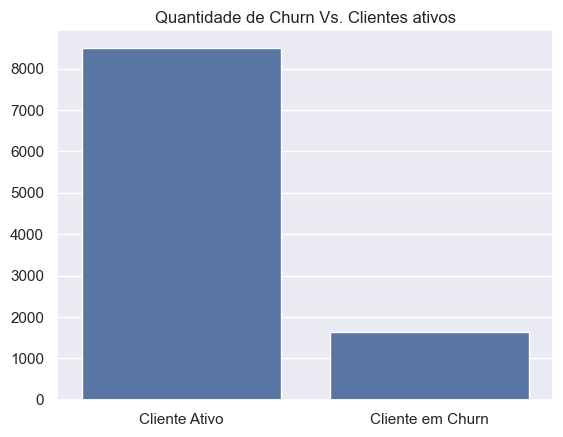

In [21]:
#Gráfico de barras da quantidade de clientes que deram churn(Attrited customer)-(1) e que não deram churn(Existing Customer)-(0):

'''Utiliza a função barplot da biblioteca Seaborn para criar um gráfico de barras.
* data=Churn_UserId: Especifica o DataFrame a ser usado, que contém as contagens de churn.
* x="Status_Churn" Define a coluna Status_Churn como o eixo x.
* y="ID_Cliente" Define a coluna ID_Cliente (que na verdade contém as contagens) como o eixo y.'''

sns.barplot(data=Churn_UserId, x = "Status_Churn", y = "ID_Cliente") 

'''Define o título do gráfico.'''

plt.title('Quantidade de Churn Vs. Clientes ativos')

'''Remove os rótulos dos eixos x e y para uma apresentação mais limpa.'''

plt.xlabel('')
plt.ylabel('')

'''Exibe o gráfico gerado.'''

plt.show()

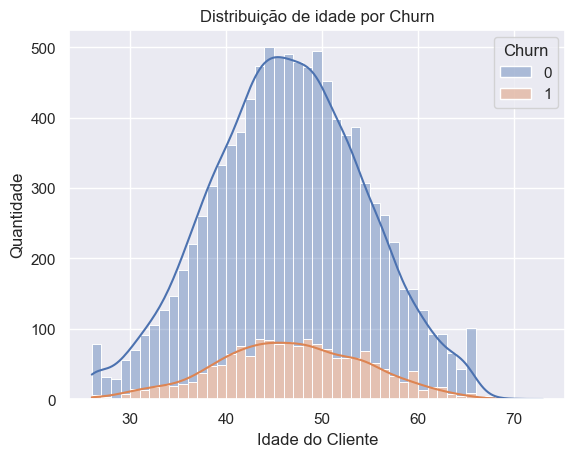

In [22]:
#histograma de distribuição de idade por Churn:

'''* sns.histplot() Cria um histograma com a biblioteca Seaborn.
   * data=Churn_df Chama para uso o DataFrame principal.
   * x='Idade_Cliente' Plota a distribuição da coluna Idade_Cliente no eixo x.
   * hue='Churn' Colore as barras de acordo com a categoria de churn (0 ou 1), permitindo a comparação das distribuições.
   * kde=True Adiciona uma linha de Estimativa de Densidade Kernel sobre o histograma para cada grupo (hue), que suaviza a distribuição.
   * multiple='stack' Empilha as barras das diferentes categorias de hue umas sobre as outras.
   * alpha=0.4: Define a transparência das barras para 40%, o que pode ajudar na visualização caso não fossem empilhadas.'''

sns.histplot(data=Churn_df, x='Idade_Cliente', hue='Churn', kde=True, multiple='stack', alpha=0.4)


'''Já explicado em célula anterior'''

plt.title('Distribuição de idade por Churn')
plt.xlabel('Idade do Cliente')
plt.ylabel('Quantidade')
plt.show()

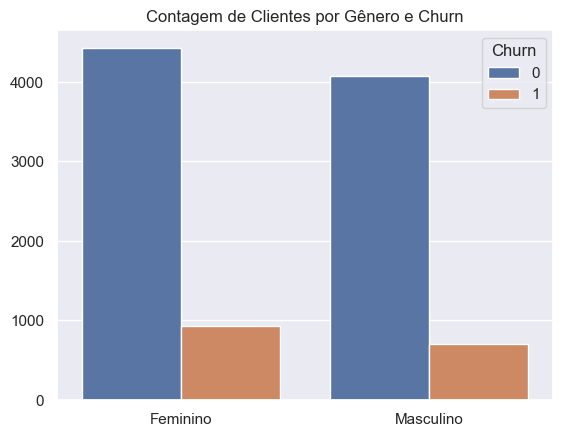

In [23]:
#gráfico de contagem de clientes por gênero e churn:

''' * sns.countplot() Utiliza a função countplot do Seaborn, que é essencialmente um histograma para variáveis categóricas.
    * x='Genero': Define a variável categórica a ser contada no eixo x.
    * hue='Churn': Separa as contagens por categoria de churn.
    * data=Churn_df: Especifica o DataFrame.'''
    
sns.countplot(x='Genero', hue='Churn', data=Churn_df)


'''Já explicado em célula anterior'''

plt.title('Contagem de Clientes por Gênero e Churn')
plt.xlabel('')
plt.ylabel('')
plt.show()

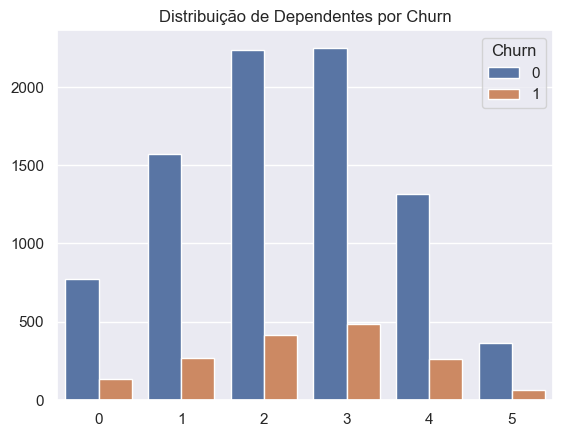

In [24]:
#gráfico de contagem de Distribuição de Dependentes por Churn

'''Já explicado em célula anterior.
A diferença é que cria um gráfico de contagem para a coluna Num_Dependentes, 
mostrando como o número de dependentes se distribui entre clientes que saíram e clientes que permaneceram'''

sns.countplot(x='Num_Dependentes', hue='Churn', data=Churn_df)

'''Já explicado em célula anterior'''

plt.title('Distribuição de Dependentes por Churn')
plt.xlabel('')
plt.ylabel('')
plt.show()

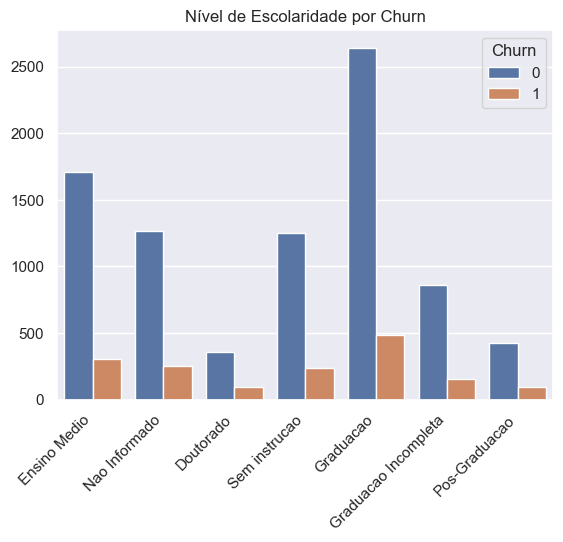

In [25]:
#gráfico de contagem de Escolaridade por Churn

'''Já explicado em célula anterior.
A diferença é que cria um gráfico de contagem para a coluna Escolaridade, 
mostrando como o número de dependentes se distribui entre clientes que saíram e clientes que permaneceram'''

sns.countplot(x='Escolaridade', hue='Churn', data=Churn_df)




'''Já explicado em célula anterior. a diferença é a linha de código plt.xticks(rotation=45, ha='right').
Esta linha rotaciona os rótulos do eixo x em 45 graus e os alinha à direita (ha='right'). 
Isso é feito para evitar que os nomes das categorias de escolaridade se sobreponham, melhorando a legibilidade.'''

plt.title('Nível de Escolaridade por Churn')
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.ylabel('')
plt.show()

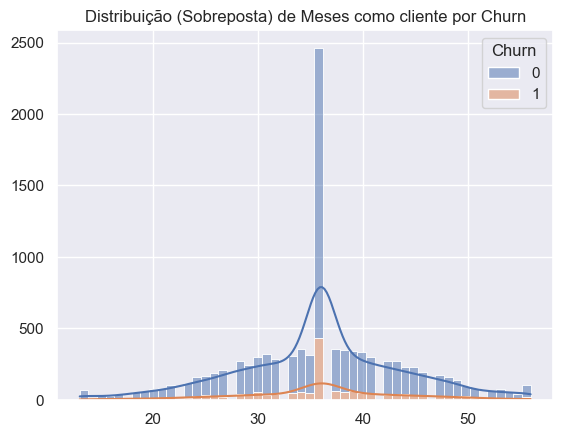

In [26]:
#gráfico de histograma de meses como cliente por Churn

'''Já explicado em célula anterior.'''
    
sns.histplot(x='Meses_Como_Cliente', hue='Churn', data=Churn_df, kde=True, multiple='stack', alpha=0.5)
plt.title('Distribuição (Sobreposta) de Meses como cliente por Churn')
plt.xlabel('')
plt.ylabel('')
plt.show()

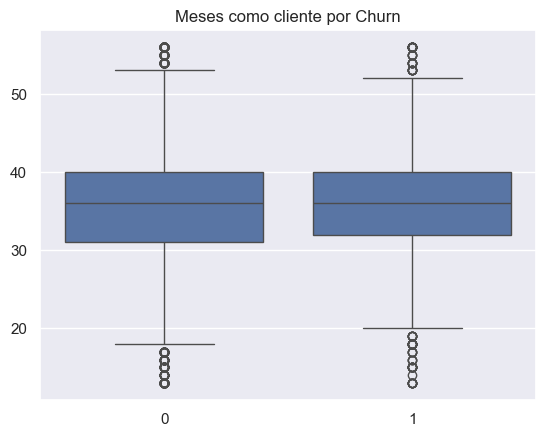

In [27]:
#gráfico de caixa de Meses como cliente por Churn 

''' * sns.boxplot(...): Utiliza a função boxplot do Seaborn para criar um diagrama de caixa.
    * x='Churn' Define a variável categórica para o eixo x.
    * y='Meses_Como_Cliente' Define a variável numérica para o eixo y.
    * data=Churn_df Especifica a fonte dos dados.
'''
sns.boxplot(x='Churn', y='Meses_Como_Cliente', data=Churn_df)

'''Já explicado em célula anterior.'''

plt.title('Meses como cliente por Churn')
plt.xlabel('')
plt.ylabel('')
plt.show()

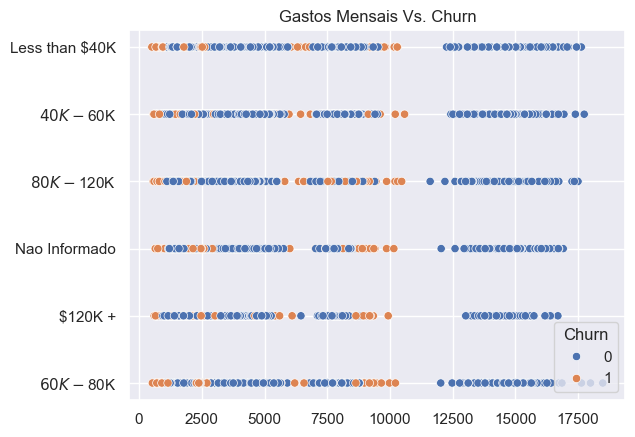

In [28]:
# gráfico de dispersão: Este gráfico ajuda a visualizar a relação entre o valor total das transações e a faixa de renda, e se há algum padrão de churn visível nessa relação.

''' * sns.scatterplot() Cria um gráfico de dispersão com o Seaborn.
    * x='Valor_Total_Transacoes' Define a variável do eixo x.
    * y='Faixa_Renda' Define a variável do eixo y.
    * hue='Churn' Colore os pontos de acordo com a categoria de churn.'''

sns.scatterplot(x='Valor_Total_Transacoes', y='Faixa_Renda', hue='Churn', data=Churn_df)


'''Já explicado em célula anterior.'''

plt.title('Gastos Mensais Vs. Churn')
plt.xlabel('')
plt.ylabel('')
plt.show()

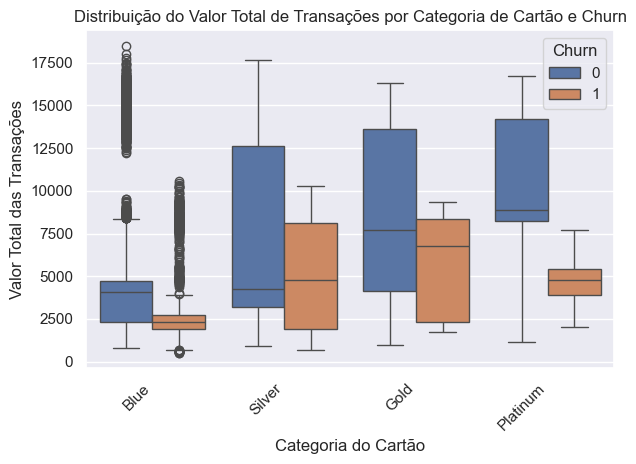

In [29]:
#gráfico de caixa Distribuição do Valor Total de Transações por Categoria de Cartão e Churn

''' * sns.boxplot() Cria outro boxplot, desta vez para comparar a distribuição do Valor_Total_Transacoes
      através das diferentes Categoria_Cartao, com a distinção de cor (hue) para o status de Churn.
    '''


sns.boxplot(x='Categoria_Cartao', y='Valor_Total_Transacoes', hue='Churn', data=Churn_df)


'''Já explicado em célula anterior:
    * plt.xticks(rotation=45, ha='right') Novamente, rotaciona os rótulos do eixo x para melhor legibilidade.
    * plt.tight_layout() Ajusta automaticamente os parâmetros do gráfico para que ele se encaixe bem na figura, evitando que os rótulos sejam cortados.'''

plt.title('Distribuição do Valor Total de Transações por Categoria de Cartão e Churn')
plt.xticks(rotation=45, ha='right') 
plt.xlabel('Categoria do Cartão') 
plt.ylabel('Valor Total das Transações') 
plt.tight_layout() 
plt.show()

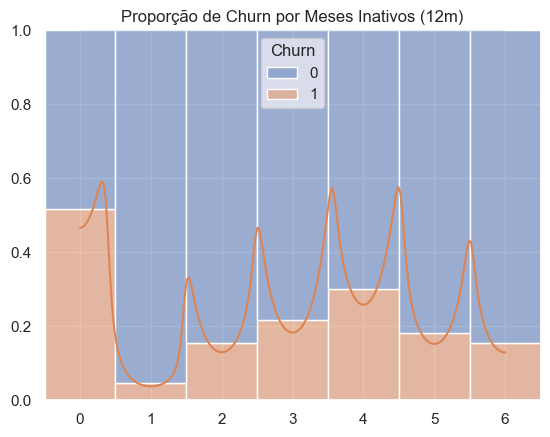

In [30]:
#gráfico de histograma para Proporção de Churn por Meses Inativos (12m)

''' * sns.histplot() Cria um histograma de proporção.
    * x='Meses_Inativo_12m' A variável no eixo x.
    * hue='Churn' A variável de separação.
    * multiple='fill' Este é o parâmetro chave aqui.
      Ele faz com que as barras sejam empilhadas e normalizadas para que a altura total de cada barra seja 1.
      Isso mostra a proporção de cada categoria de hue dentro de cada bin do eixo x.
    * discrete=True Trata a variável do eixo x como categórica, mesmo sendo numérica.
    * stat='probability' Garante que o eixo y represente a probabilidade (ou proporção).'''

sns.histplot(x='Meses_Inativo_12m',hue='Churn', kde=True, data=Churn_df,  multiple='fill', discrete=True, stat='probability')


'''Já explicado em célula anterior.'''

plt.title('Proporção de Churn por Meses Inativos (12m)')
plt.xlabel('')
plt.ylabel('')
plt.show()

##### 3. Preparando e modelando os Dados

In [31]:
#conferindo DataFrame
'''Já explicado em célula anterior.'''
Churn_df.head()

,ID_Cliente,Status_Churn,Idade_Cliente,Genero,Num_Dependentes,Escolaridade,Estado_Civil,Faixa_Renda,Categoria_Cartao,Meses_Como_Cliente,...,Saldo_Rotativo_Total,Media_Disponivel_Compra,Var_Total_Valor_Q4_Q1,Valor_Total_Transacoes,Cont_Total_Transacoes,Var_Total_Cont_Q4_Q1,Taxa_Media_Utilizacao,Classificador_Naive_Bayes_1,Classificador_Naive_Bayes_2,Churn
0,708082083,Cliente Ativo,45,Feminino,3,Ensino Medio,Casado(a),Less than $40K,Blue,36,...,1661,1883.0,0.831,15149,111,0.734,0.469,0.000305,0.999690,0
1,708083283,Cliente em Churn,58,Masculino,0,Nao Informado,Solteiro(a),$40K - $60K,Blue,45,...,2517,904.0,0.992,992,21,0.400,0.736,0.988690,0.011310,1
2,708084558,Cliente em Churn,46,Masculino,3,Doutorado,Divorciado(a),$80K - $120K,Blue,38,...,1771,6487.0,0.000,1447,23,0.000,0.214,0.997800,0.002196,1
3,708085458,Cliente Ativo,34,Feminino,2,Sem instrucao,Solteiro(a),Less than $40K,Blue,24,...,0,1438.3,0.827,3940,82,0.952,0.000,0.000117,0.999880,0
4,708086958,Cliente Ativo,49,Feminino,2,Sem instrucao,Casado(a),Nao Informado,Blue,41,...,749,2379.0,0.598,4369,59,0.735,0.239,0.000207,0.999790,0


In [32]:
# calculando a medida estatística da curtose para os dados da coluna "Meses_Como_Cliente"

''' * Churn_df['Meses_Como_Cliente'].kurt() Seleciona a coluna Meses_Como_Cliente e aplica o método .kurt(), que calcula a curtose da distribuição dos dados.
      A curtose é uma medida da "cauda" da distribuição, indicando a frequência de valores extremos.
    * print() Imprime o valor da curtose em uma frase formatada.'''

print('A curtose da coluna "Meses_Como_Cliente" é : {}'.format(Churn_df['Meses_Como_Cliente'].kurt()))

A curtose da coluna "Meses_Como_Cliente" é : 0.4001001201998675


In [33]:
'''Cria uma instância do objeto LabelEncoder.'''

le = LabelEncoder()

'''Define uma lista com os nomes das colunas categóricas que precisam ser transformadas em números.'''

Categorical_cols = ['Genero', 'Escolaridade', 'Estado_Civil', 'Categoria_Cartao']

''' * for col in Categorical_cols: Inicia um loop que passará por cada nome de coluna na lista Categorical_cols.
    * Churn_df[col] = le.fit_transform(Churn_df[col]) Dentro do loop, para cada coluna:
      * le.fit_transform(Churn_df[col]): O método fit_transform primeiro aprende as categorias únicas na coluna (fit) 
        e depois as transforma em números inteiros sequenciais (0, 1, 2, ...) (transform).
      * Churn_df[col]:  O resultado (a coluna agora numérica) substitui a coluna original no DataFrame.
    * Churn_df.head(): Após o loop, exibe as primeiras 5 linhas para verificar se as colunas selecionadas foram convertidas para números.'''
    
for col in Categorical_cols:
  Churn_df[col] = le.fit_transform(Churn_df[col])
  #conferindo a alteração
Churn_df.head()

,ID_Cliente,Status_Churn,Idade_Cliente,Genero,Num_Dependentes,Escolaridade,Estado_Civil,Faixa_Renda,Categoria_Cartao,Meses_Como_Cliente,...,Saldo_Rotativo_Total,Media_Disponivel_Compra,Var_Total_Valor_Q4_Q1,Valor_Total_Transacoes,Cont_Total_Transacoes,Var_Total_Cont_Q4_Q1,Taxa_Media_Utilizacao,Classificador_Naive_Bayes_1,Classificador_Naive_Bayes_2,Churn
0,708082083,Cliente Ativo,45,0,3,1,0,Less than $40K,0,36,...,1661,1883.0,0.831,15149,111,0.734,0.469,0.000305,0.999690,0
1,708083283,Cliente em Churn,58,1,0,4,3,$40K - $60K,0,45,...,2517,904.0,0.992,992,21,0.400,0.736,0.988690,0.011310,1
2,708084558,Cliente em Churn,46,1,3,0,1,$80K - $120K,0,38,...,1771,6487.0,0.000,1447,23,0.000,0.214,0.997800,0.002196,1
3,708085458,Cliente Ativo,34,0,2,6,3,Less than $40K,0,24,...,0,1438.3,0.827,3940,82,0.952,0.000,0.000117,0.999880,0
4,708086958,Cliente Ativo,49,0,2,6,0,Nao Informado,0,41,...,749,2379.0,0.598,4369,59,0.735,0.239,0.000207,0.999790,0


In [34]:
#Normalização dos dados

'''Cria uma instância do MinMaxScaler
'''
scaler = MinMaxScaler()

'''Define uma lista com os nomes de algumas colunas numéricas que serão normalizadas.'''

numeric_features = ['Cont_Total_Relacionamento','Taxa_Media_Utilizacao', 'Meses_Como_Cliente', 'Valor_Total_Transacoes']


'''Seleciona as colunas da lista numeric_features e aplica o MinMaxScaler. O fit_transform calcula os valores mínimo e máximo de cada coluna (fit)
e, em seguida, os utiliza para escalar os dados para o intervalo [0, 1] (transform). 
As colunas originais são substituídas pelas versões normalizadas.'''

Churn_df[numeric_features] = scaler.fit_transform(Churn_df[numeric_features])


#conferindo a alteração
'''Já explicado em célula anterior.'''

Churn_df.head()

,ID_Cliente,Status_Churn,Idade_Cliente,Genero,Num_Dependentes,Escolaridade,Estado_Civil,Faixa_Renda,Categoria_Cartao,Meses_Como_Cliente,...,Saldo_Rotativo_Total,Media_Disponivel_Compra,Var_Total_Valor_Q4_Q1,Valor_Total_Transacoes,Cont_Total_Transacoes,Var_Total_Cont_Q4_Q1,Taxa_Media_Utilizacao,Classificador_Naive_Bayes_1,Classificador_Naive_Bayes_2,Churn
0,708082083,Cliente Ativo,45,0,3,1,0,Less than $40K,0,0.534884,...,1661,1883.0,0.831,0.814454,111,0.734,0.469469,0.000305,0.999690,0
1,708083283,Cliente em Churn,58,1,0,4,3,$40K - $60K,0,0.744186,...,2517,904.0,0.992,0.026817,21,0.400,0.736737,0.988690,0.011310,1
2,708084558,Cliente em Churn,46,1,3,0,1,$80K - $120K,0,0.581395,...,1771,6487.0,0.000,0.052131,23,0.000,0.214214,0.997800,0.002196,1
3,708085458,Cliente Ativo,34,0,2,6,3,Less than $40K,0,0.255814,...,0,1438.3,0.827,0.190831,82,0.952,0.000000,0.000117,0.999880,0
4,708086958,Cliente Ativo,49,0,2,6,0,Nao Informado,0,0.651163,...,749,2379.0,0.598,0.214699,59,0.735,0.239239,0.000207,0.999790,0


In [35]:
# 1. Definir X (features) e y (target)
# Colunas a serem removidas para criar X (ajuste conforme suas features finais)
print("--- Etapa 1: Definindo X e y ---")

'''Define uma lista de colunas que não serão usadas como features (variáveis preditoras) para o modelo.
Inclui identificadores (ID_Cliente), a variável alvo em suas duas formas (Churn, Status_Churn)
e as colunas do Naive Bayes que vieram no dataset original.'''

cols_to_drop_for_X = [
    'ID_Cliente',
    'Churn',
    'Status_Churn',
    'Classificador_Naive_Bayes_1',
    'Classificador_Naive_Bayes_2'
]

'''Cria o DataFrame de features X removendo as colunas especificadas da lista
cols_to_drop_for_X do DataFrame principal. axis=1 indica que estamos removendo colunas.'''

X = Churn_df.drop(columns=cols_to_drop_for_X, axis=1)


# Definindo y_alvo com uma Series Pandas 1D com 0s e 1s
'''Cria a série (vetor) alvo y_alvo selecionando a coluna Churn (que contém os valores 0 e 1).'''
y_alvo = Churn_df['Churn']

'''prints servem para verificar as dimensões e o conteúdo de X e y_alvo, garantindo que a separação foi feita corretamente.'''
print("Shape de X:", X.shape)
print("Shape de y_alvo:", y_alvo.shape)
print("Primeiras linhas de X:")
print(X.head())
print("\nValores únicos em y_alvo:", y_alvo.unique())

# Codificar a variável alvo 'y' para numérica ANTES da divisão
'''Este trecho aplica o LabelEncoder na variável alvo.'''
'''Depois devo verificar se a remoção das próximas duas linhas afetará o código pois como a coluna Churn já foi convertida para 0 e 1, talvez esta etapa seja redundante'''
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y_alvo) # y_encoded é agora um array NumPy 1D


--- Etapa 1: Definindo X e y ---
Shape de X: (10127, 19)
Shape de y_alvo: (10127,)
Primeiras linhas de X:
   Idade_Cliente  Genero  Num_Dependentes  Escolaridade  Estado_Civil  \
0             45       0                3             1             0   
1             58       1                0             4             3   
2             46       1                3             0             1   
3             34       0                2             6             3   
4             49       0                2             6             0   

      Faixa_Renda  Categoria_Cartao  Meses_Como_Cliente  \
0  Less than $40K                 0            0.534884   
1     $40K - $60K                 0            0.744186   
2    $80K - $120K                 0            0.581395   
3  Less than $40K                 0            0.255814   
4   Nao Informado                 0            0.651163   

   Cont_Total_Relacionamento  Meses_Inativo_12m  Cont_Contatos_12m  \
0                        0.6  

In [36]:
# 2. Dividir em conjuntos de treino e teste ANTES de qualquer reamostragem ou escalonamento que cause data leakage
print("\n--- Etapa 2: Divisão Treino-Teste ---")


''' * X_train, X_test, y_train, y_test = train_test_split(): Utiliza a função importada para dividir os dados.
    * X, y_alvo: Os dados de features e alvo a serem divididos.
    * test_size=0.25: Define que 25% dos dados serão alocados para o conjunto de teste (X_test, y_test), 
      e os 75% restantes para o treino (X_train, y_train).
    * random_state=42: Fixa uma "semente" para a aleatoriedade da divisão. Isso garante que, sempre que o código for executado,
      a divisão será exatamente a mesma, o que é crucial para a reprodutibilidade dos resultados.
    * stratify=y_alvo: Parâmetro muito importante para dados desbalanceados. 
      Ele garante que a proporção de classes (churn vs. não churn) nos conjuntos de treino e teste seja a mesma que no conjunto de dados original.'''

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_alvo,
    test_size=0.25,       # 25% dos dados para teste
    random_state=42,      # Para reprodutibilidade
    stratify=y_alvo       # Para manter a proporção das classes em y
)

'''exibem as dimensões dos novos DataFrames/Séries de treino e teste.'''

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)


--- Etapa 2: Divisão Treino-Teste ---
Shape de X_train: (7595, 19)
Shape de X_test: (2532, 19)
Shape de y_train: (7595,)
Shape de y_test: (2532,)


In [37]:
# ETAPA 3: PRÉ-PROCESSAMENTO DAS FEATURES (APÓS A DIVISÃO)

# 3A. ONE-HOT ENCODING PARA COLUNAS CATEGÓRICAS EM X (com pd.get_dummies)
print("\n--- Etapa 3A: One-Hot Encoding (get_dummies) ---")
# Identificar colunas que ainda são do tipo 'object' (texto) em X_train
'''Identifica automaticamente as colunas que ainda são do tipo object (texto) no conjunto de treino. Neste caso, será apenas a Faixa_Renda.'''

colunas_categoricas_para_dummies = X_train.select_dtypes(include='object').columns.tolist()


# Verificação IMPORTANTE:
print(f"Colunas categóricas identificadas em X_train para dummificar: {colunas_categoricas_para_dummies}")


'''Uma verificação para executar o código apenas se houver colunas categóricas a serem codificadas.'''
if colunas_categoricas_para_dummies:
    print(f"Colunas categóricas para One-Hot Encoding: {colunas_categoricas_para_dummies}")
    
    '''Utiliza a função get_dummies do Pandas para realizar o One-Hot Encoding.
    Ela transforma a coluna Faixa_Renda em várias novas colunas binárias (0 ou 1), onde cada nova coluna representa uma categoria da Faixa_Renda original.'''
    X_train = pd.get_dummies(X_train, columns=colunas_categoricas_para_dummies, prefix=colunas_categoricas_para_dummies, dummy_na=False)
    '''Aplica a mesma transformação ao conjunto de teste.'''
    X_test = pd.get_dummies(X_test, columns=colunas_categoricas_para_dummies, prefix=colunas_categoricas_para_dummies, dummy_na=False)


    # Alinhar colunas para garantir que X_test tenha as mesmas colunas que X_train
    # (preenchendo com 0 se alguma categoria do treino não existir no teste)
    '''Armazena os nomes de todas as colunas do X_train após a dummificação.'''
    
    X_train_cols = X_train.columns
    
    ''' Esta é uma etapa crucial. Ela alinha as colunas de X_test para que sejam exatamente as mesmas de X_train. 
    Se uma categoria de renda existia no treino mas não no teste, a coluna correspondente será adicionada ao X_test e preenchida com zeros.
    Isso evita erros durante a predição.'''
    X_test = X_test.reindex(columns=X_train_cols, fill_value=0)
    # Garantir que X_train também só tenha essas colunas (caso raro de X_test ter uma categoria nova não vista no prefixo)
    '''Boa prática: verificação de segurança para garantir que X_train também tenha o mesmo conjunto de colunas'''
    X_train = X_train.reindex(columns=X_train_cols, fill_value=0)

    print("Shapes após get_dummies e alinhamento:")
    print("Shape de X_train:", X_train.shape)
    print("Shape de X_test:", X_test.shape)
else:
    print("Nenhuma coluna do tipo 'object' encontrada em X_train para aplicar pd.get_dummies.")
    # Isso aconteceria se todas as suas features em X já fossem numéricas.


--- Etapa 3A: One-Hot Encoding (get_dummies) ---
Colunas categóricas identificadas em X_train para dummificar: ['Faixa_Renda']
Colunas categóricas para One-Hot Encoding: ['Faixa_Renda']
Shapes após get_dummies e alinhamento:
Shape de X_train: (7595, 24)
Shape de X_test: (2532, 24)


In [38]:
#   3B. ESCALONAMENTO DE FEATURES NUMÉRICAS (MinMaxScaler)
print("\n--- Etapa 3B: Escalonamento (MinMaxScaler) ---")
# Neste ponto, todas as colunas em X_train e X_test devem ser numéricas.

'''Define que todas as colunas (agora numéricas) serão escaladas.'''

colunas_para_escalar = X_train.columns # Todas as colunas de X_train

'''Cria uma nova instância do MinMaxScaler.'''
scaler = MinMaxScaler()


# Guardar índices para reconstrução (opcional, mas boa prática se precisar do índice original)
'''Guardam os índices originais para poder reconstruir os DataFrames corretamente após o escalonamento.'''
X_train_index = X_train.index
X_test_index = X_test.index

# Ajustar (fit) o scaler SOMENTE em X_train e transformar ambos
'''Ajusta o scaler aos dados de treino (aprendendo os valores mínimo e máximo de cada coluna) e, em seguida, transforma esses dados.'''
X_train_scaled_array = scaler.fit_transform(X_train[colunas_para_escalar])
'''Apenas transforma os dados de teste usando os parâmetros (mínimos e máximos) aprendidos com os dados de treino. Isso é fundamental para evitar vazamento de dados.'''
X_test_scaled_array = scaler.transform(X_test[colunas_para_escalar])

# Converter de volta para DataFrames (mantendo nomes de colunas e índices)
'''Convertem os arrays NumPy resultantes do escalonamento de volta para DataFrames Pandas, restaurando os nomes das colunas e os índices.'''
X_train = pd.DataFrame(X_train_scaled_array, columns=colunas_para_escalar, index=X_train_index)
X_test = pd.DataFrame(X_test_scaled_array, columns=colunas_para_escalar, index=X_test_index)

print("Primeiras linhas de X_train escalado:")
print(X_train.head())


--- Etapa 3B: Escalonamento (MinMaxScaler) ---
Primeiras linhas de X_train escalado:
      Idade_Cliente  Genero  Num_Dependentes  Escolaridade  Estado_Civil  \
9620       0.928571     1.0              0.2      0.000000           1.0   
1769       0.166667     1.0              0.8      0.166667           1.0   
8737       0.095238     1.0              0.0      0.166667           0.0   
5090       0.071429     0.0              0.0      0.166667           1.0   
2826       0.523810     0.0              0.8      0.500000           0.0   

      Categoria_Cartao  Meses_Como_Cliente  Cont_Total_Relacionamento  \
9620               0.0            1.000000                        0.8   
1769               0.0            0.279070                        0.6   
8737               0.0            0.186047                        0.8   
5090               0.0            0.000000                        1.0   
2826               0.0            0.534884                        0.2   

      Meses_Inativ

In [39]:
# ETAPA 4: BALANCEAMENTO DAS CLASSES COM SMOTE (SOMENTE nos dados de treino)
print("\n--- Etapa 4: Balanceamento com SMOTE ---") # Mostra a contagem de classes antes da aplicação do SMOTE para comparação.
print(f"Contagem de classes em y_train ANTES do SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
smote = SMOTE(random_state=42) #  Cria uma instância do SMOTE, com random_state para reprodutibilidade.

# X_train e y_train aqui são os pré-processados da etapa anterior
'''Aplica a técnica SMOTE. Ele "aprende" com os dados de treino (fit) e gera novas amostras sintéticas da classe minoritária (churn=1)
para igualar o número de amostras da classe majoritária, criando novos conjuntos X_train_resampled e y_train_resampled balanceados.'''

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

'''mostram a contagem de classes após o SMOTE, confirmando que as classes agora estão balanceadas, e as novas dimensões dos dados de treino.'''
print(f"Contagem de classes em y_train APÓS o SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}")
print("Shape de X_train_resampled:", X_train_resampled.shape)
print("Shape de y_train_resampled:", y_train_resampled.shape)


--- Etapa 4: Balanceamento com SMOTE ---
Contagem de classes em y_train ANTES do SMOTE: {0: 6375, 1: 1220}
Contagem de classes em y_train APÓS o SMOTE: {0: 6375, 1: 6375}
Shape de X_train_resampled: (12750, 24)
Shape de y_train_resampled: (12750,)



--- Etapa 5A: Modelagem (Exemplo Regressão Logística) ---

--- Regressão Logística ---

--- Resultados da Regressão Logística ---


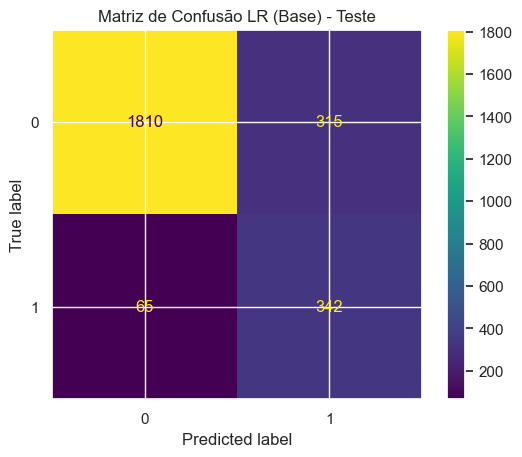

Acurácia LR (Treino Resampled): 0.8648627450980392
Acurácia LR (Teste): 0.8499210110584519
ROCAUC LR (Treino Resampled): 0.9371278861976161
ROCAUC LR (Teste): 0.9268657320422026


In [237]:
# ETAPA 5A: MODELAGEM (EXEMPLO COM REGRESSÃO LOGÍSTICA)
print("\n--- Etapa 5A: Modelagem (Exemplo Regressão Logística) ---")
# Usar X_train_resampled e y_train_resampled para treinar
# Usar X_test (processado) e y_test para avaliar

''' * lr_model = LogisticRegression(): Cria uma instância do modelo de Regressão Logística.
    * random_state=42: Garante reprodutibilidade nos resultados do modelo.
    * max_iter=1000: Aumenta o número máximo de iterações para garantir que o modelo convirja.
    * solver='liblinear': Especifica o algoritmo a ser usado na otimização, uma boa escolha para datasets menores.'''

lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear') 


lr_model.fit(X_train_resampled, y_train_resampled) #Treina o modelo de regressão logística usando os dados de treino que foram balanceados com SMOTE.

# Predições
y_pred_lr_train = lr_model.predict(X_train_resampled) #Usa o modelo treinado para fazer predições de classe (0 ou 1) no conjunto de teste.
y_pred_lr_test = lr_model.predict(X_test)
y_proba_lr_test = lr_model.predict_proba(X_test)[:, 1]  # Gera as probabilidades de predição para cada classe e seleciona ([:, 1]) apenas a probabilidade da classe positiva (churn=1).

# Modelagem com Regressão Logística
print("\n--- Regressão Logística ---")
lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')
lr_model.fit(X_train_resampled, y_train_resampled)

# Predições
y_pred_lr_train = lr_model.predict(X_train_resampled) #VERIFICAR A REDUNDANCIA
y_pred_lr_test = lr_model.predict(X_test) 
y_proba_lr_train = lr_model.predict_proba(X_train_resampled)[:, 1]
y_proba_lr_test = lr_model.predict_proba(X_test)[:, 1]

# Avaliação
print("\n--- Resultados da Regressão Logística ---")
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test, values_format="d") # Gera e plota a matriz de confusão para os dados de teste.
plt.title("Matriz de Confusão LR (Base) - Teste")                                  
plt.show()                                                                        

print(f"Acurácia LR (Treino Resampled): {accuracy_score(y_train_resampled, y_pred_lr_train)}")
print(f"Acurácia LR (Teste): {accuracy_score(y_test, y_pred_lr_test)}")
print(f"ROCAUC LR (Treino Resampled): {roc_auc_score(y_train_resampled, y_proba_lr_train)}")
print(f"ROCAUC LR (Teste): {roc_auc_score(y_test, y_proba_lr_test)}")
#print(classification_report(y_test, y_pred_lr_test))


--- Etapa 5B: Tuning da Regressão Logística ---
Iniciando o GridSearchCV para Regressão Logística...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores Parâmetros para Regressão Logística: {'C': 10, 'penalty': 'l1'}
Melhor Score ROCAUC (CV) para Regressão Logística: 0.9368370934256056

--- Resultados da Regressão Logística Tunada ---


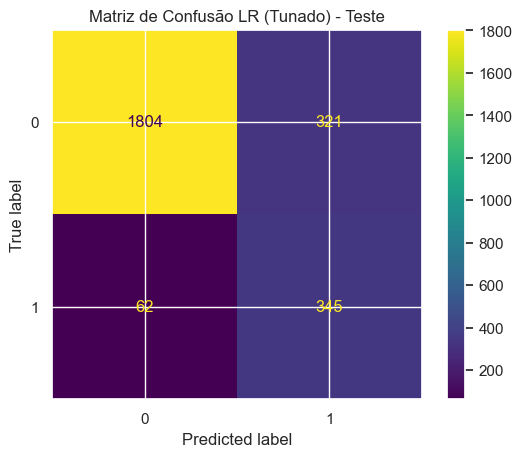

Acurácia LR Tuned (Treino Resampled): 0.8669803921568627
Acurácia LR Tuned (Teste): 0.8487361769352291
Acurácia Balanceada LR Tuned (Treino Resampled): 0.8669803921568627
Acurácia Balanceada LR Tuned (Teste): 0.8483035120682179
Precision LR Tuned (Teste, pos_label=1): 0.5180180180180181
Recall LR Tuned (Teste, pos_label=1): 0.8476658476658476
F1-Score LR Tuned (Teste, pos_label=1): 0.6430568499534017
ROCAUC LR Tuned (Treino Resampled): 0.9375428650519032
ROCAUC LR Tuned (Teste): 0.9277999710940887


In [40]:
# --- ETAPA 5B: Tuning da Regressão Logística com GridSearchCV ---
print("\n--- Etapa 5B: Tuning da Regressão Logística ---")

# Definindo a grade de parâmetros que você quer testar
'''Define um dicionário com os hiperparâmetros a serem testados. C é o parâmetro de regularização e penalty é o tipo de regularização (L1 ou L2).'''
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100], # Adicionei 100 para testar regularização mais fraca
                 'penalty': ['l1', 'l2']}

# Criando o objeto GridSearchCV

''' * grid_search_lr = GridSearchCV(): Cria uma instância do GridSearchCV.
    * LogisticRegression(): O modelo base a ser otimizado.
    * param_grid_lr: A grade de parâmetros a ser testada.
    * scoring='roc_auc': A métrica a ser usada para avaliar qual combinação de parâmetros é a melhor.
    * cv=5: Define que a validação cruzada será feita com 5 folds (divisões).
    * n_jobs=-1: Usa todos os núcleos de CPU disponíveis para acelerar o processo.
    * verbose=1: Imprime o progresso da busca na tela.'''
    
grid_search_lr = GridSearchCV(
    LogisticRegression(solver='liblinear', random_state=42, max_iter=1000),
    param_grid_lr,
    scoring='roc_auc', # Usar roc_auc é geralmente bom para dados com histórico de desbalanceamento.
    cv=5,              
    n_jobs=-1,         
    verbose=1          
)

# Ajustando o GridSearchCV com os dados de treino reamostrados
print("Iniciando o GridSearchCV para Regressão Logística...")

'''Executa a busca em grade nos dados de treino reamostrados. Ele treina e avalia o modelo para cada combinação de parâmetros.'''
grid_search_lr.fit(X_train_resampled, y_train_resampled)

# Obtendo o melhor estimador (modelo com os melhores parâmetros)

'''Após a busca, esta linha extrai o melhor modelo (com os melhores hiperparâmetros encontrados) e o armazena em lr_tuned.'''
lr_tuned = grid_search_lr.best_estimator_

print(f"Melhores Parâmetros para Regressão Logística: {grid_search_lr.best_params_}")
print(f"Melhor Score ROCAUC (CV) para Regressão Logística: {grid_search_lr.best_score_}")

# --- Avaliação do Modelo de Regressão Logística Tunado ---
print("\n--- Resultados da Regressão Logística Tunada ---")

# Predições com o modelo tunado já explicado em célula anterior
y_pred_lr_tuned_train = lr_tuned.predict(X_train_resampled)
y_pred_lr_tuned_test = lr_tuned.predict(X_test)
y_proba_lr_tuned_train = lr_tuned.predict_proba(X_train_resampled)[:, 1]
y_proba_lr_tuned_test = lr_tuned.predict_proba(X_test)[:, 1]

# Matriz de Confusão
ConfusionMatrixDisplay.from_estimator(lr_tuned, X_test, y_test, values_format="d")
plt.title("Matriz de Confusão LR (Tunado) - Teste")
plt.show()

# Métricas
print(f"Acurácia LR Tuned (Treino Resampled): {accuracy_score(y_train_resampled, y_pred_lr_tuned_train)}")
print(f"Acurácia LR Tuned (Teste): {accuracy_score(y_test, y_pred_lr_tuned_test)}")
print(f"Acurácia Balanceada LR Tuned (Treino Resampled): {balanced_accuracy_score(y_train_resampled, y_pred_lr_tuned_train)}") # Adicionando Acurácia Balanceada
print(f"Acurácia Balanceada LR Tuned (Teste): {balanced_accuracy_score(y_test, y_pred_lr_tuned_test)}")                  # Adicionando Acurácia Balanceada
print(f"Precision LR Tuned (Teste, pos_label=1): {precision_score(y_test, y_pred_lr_tuned_test, pos_label=1)}")         # Adicionando Precision
print(f"Recall LR Tuned (Teste, pos_label=1): {recall_score(y_test, y_pred_lr_tuned_test, pos_label=1)}")                # Adicionando Recall
print(f"F1-Score LR Tuned (Teste, pos_label=1): {f1_score(y_test, y_pred_lr_tuned_test, pos_label=1)}")                   # Adicionando F1-Score
print(f"ROCAUC LR Tuned (Treino Resampled): {roc_auc_score(y_train_resampled, y_proba_lr_tuned_train)}")
print(f"ROCAUC LR Tuned (Teste): {roc_auc_score(y_test, y_proba_lr_tuned_test)}")

#  classification_report completo para o modelo tunado
#print("\nRelatório de Classificação Regressão Logística Tuned (Teste):")
#print(classification_report(y_test, y_pred_lr_tuned_test))


--- Random Forest (Base) ---
Treinando o modelo Random Forest (Base)...
Treinamento concluído.

--- Resultados do Random Forest (Base) ---


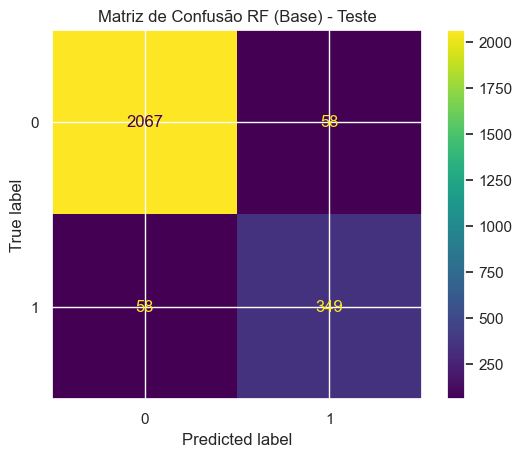


Métricas de Treino (Resampled) para Random Forest (Base):
Acurácia: 1.0
Acurácia Balanceada: 1.0
Precision (pos_label=1): 1.0
Recall (pos_label=1): 1.0
F1-Score (pos_label=1): 1.0
ROCAUC: 1.0

Métricas de Teste para Random Forest (Base):
Acurácia: 0.9541864139020537
Acurácia Balanceada: 0.9150998699233994
Precision (pos_label=1): 0.8574938574938575
Recall (pos_label=1): 0.8574938574938575
F1-Score (pos_label=1): 0.8574938574938575
ROCAUC: 0.9846359300476948


In [239]:
# --- Random Forest (Base) ---
print("\n--- Random Forest (Base) ---")

# 1. Criar a instância do modelo Random Forest
#    Adicionar random_state para reprodutibilidade
'''Cria uma instância do modelo Random Forest com seus parâmetros padrão, definindo random_state para reprodutibilidade.'''

rf_model_base = RandomForestClassifier(random_state=42) 

# 2. Treinar o modelo com os dados de treino reamostrados(balanceados)
print("Treinando o modelo Random Forest (Base)...")
rf_model_base.fit(X_train_resampled, y_train_resampled)
print("Treinamento concluído.")

# 3. Fazer predições
# Predições no conjunto de treino (reamostrado)
y_pred_rf_base_train = rf_model_base.predict(X_train_resampled)
y_proba_rf_base_train = rf_model_base.predict_proba(X_train_resampled)[:, 1]

# Predições no conjunto de teste
y_pred_rf_base_test = rf_model_base.predict(X_test)
y_proba_rf_base_test = rf_model_base.predict_proba(X_test)[:, 1]

# 4. Avaliação do modelo
print("\n--- Resultados do Random Forest (Base) ---")

# Matriz de Confusão para o conjunto de teste
ConfusionMatrixDisplay.from_estimator(rf_model_base, X_test, y_test, values_format="d")
plt.title("Matriz de Confusão RF (Base) - Teste")
plt.show()

# Métricas para Treino (Resampled)
print("\nMétricas de Treino (Resampled) para Random Forest (Base):")
print(f"Acurácia: {accuracy_score(y_train_resampled, y_pred_rf_base_train)}")
print(f"Acurácia Balanceada: {balanced_accuracy_score(y_train_resampled, y_pred_rf_base_train)}")
print(f"Precision (pos_label=1): {precision_score(y_train_resampled, y_pred_rf_base_train, pos_label=1, zero_division=0)}")
print(f"Recall (pos_label=1): {recall_score(y_train_resampled, y_pred_rf_base_train, pos_label=1, zero_division=0)}")
print(f"F1-Score (pos_label=1): {f1_score(y_train_resampled, y_pred_rf_base_train, pos_label=1, zero_division=0)}")
print(f"ROCAUC: {roc_auc_score(y_train_resampled, y_proba_rf_base_train)}")

# Métricas para Teste
print("\nMétricas de Teste para Random Forest (Base):")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf_base_test)}")
print(f"Acurácia Balanceada: {balanced_accuracy_score(y_test, y_pred_rf_base_test)}")
print(f"Precision (pos_label=1): {precision_score(y_test, y_pred_rf_base_test, pos_label=1, zero_division=0)}")
print(f"Recall (pos_label=1): {recall_score(y_test, y_pred_rf_base_test, pos_label=1, zero_division=0)}")
print(f"F1-Score (pos_label=1): {f1_score(y_test, y_pred_rf_base_test, pos_label=1, zero_division=0)}")
print(f"ROCAUC: {roc_auc_score(y_test, y_proba_rf_base_test)}")

#print("\nRelatório de Classificação Random Forest (Base) - Teste:")
#print(classification_report(y_test, y_pred_rf_base_test, zero_division=0))


--- Random Forest (Tuning) ---
Iniciando o GridSearchCV para Random Forest...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
GridSearchCV concluído.

Melhores Parâmetros para Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Melhor Score ROCAUC (CV) para Random Forest: 0.996486828143022

--- Resultados do Random Forest (Tunado) ---


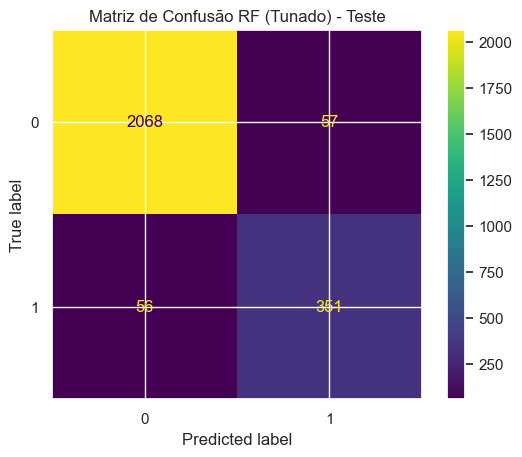


Métricas de Treino (Resampled) para Random Forest (Tunado):
Acurácia: 1.0
Acurácia Balanceada: 1.0
Precision (pos_label=1): 1.0
Recall (pos_label=1): 1.0
F1-Score (pos_label=1): 1.0
ROCAUC: 1.0

Métricas de Teste para Random Forest (Tunado):
Acurácia: 0.9553712480252765
Acurácia Balanceada: 0.9177921664980488
Precision (pos_label=1): 0.8602941176470589
Recall (pos_label=1): 0.8624078624078624
F1-Score (pos_label=1): 0.8613496932515338
ROCAUC: 0.9860754444283856
Valor MÍNIMO em y_proba_rf_tuned_test: 0.0
Valor MÁXIMO em y_proba_rf_tuned_test: 1.0
Número de valores > 1 em y_proba_rf_tuned_test: 0
Número de valores < 0 em y_proba_rf_tuned_test: 0


In [240]:
# --- Tuning da Random Forest com GridSearchCV ---
print("\n--- Random Forest (Tuning) ---")

# 1. Definir a grade de hiperparâmetros para testar
# Usando um param_grid similar ao que gerou seus bons resultados anteriores
'''Define uma grade de hiperparâmetros específicos para o Random Forest (n_estimators, max_depth, etc.) para serem testados.'''
param_grid_rf = {
    'n_estimators': [100, 200, 300],  # Número de árvores
    'max_depth': [10, 15, None],       # Profundidade máxima. None = sem limite.
    'min_samples_split': [2, 5, 10],   # Mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4]      # Mínimo de amostras em um nó folha
}

# 2. Criar o objeto GridSearchCV
#    - RandomForestClassifier(random_state=42) para reprodutibilidade do classificador base.
#    - scoring='roc_auc' é uma boa métrica para otimizar, especialmente com dados que foram desbalanceados.
#    - cv=3 (ou 5) para o número de folds da validação cruzada. cv=3 é mais rápido.
#    - n_jobs=-1 para usar todos os processadores disponíveis.
#    - verbose=1 para ver o progresso.
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 3. Ajustar o GridSearchCV com os dados de treino reamostrados
print("Iniciando o GridSearchCV para Random Forest...")
grid_search_rf.fit(X_train_resampled, y_train_resampled)
print("GridSearchCV concluído.")

# 4. Obter o melhor estimador (modelo com os melhores parâmetros) e os melhores parâmetros
rf_tuned = grid_search_rf.best_estimator_
print(f"\nMelhores Parâmetros para Random Forest: {grid_search_rf.best_params_}")
print(f"Melhor Score ROCAUC (CV) para Random Forest: {grid_search_rf.best_score_}")



# 5. Fazer predições com o modelo tunado
# Predições no conjunto de treino (reamostrado)
y_pred_rf_tuned_train = rf_tuned.predict(X_train_resampled)
y_proba_rf_tuned_train = rf_tuned.predict_proba(X_train_resampled)[:, 1]

# Predições no conjunto de teste
y_pred_rf_tuned_test = rf_tuned.predict(X_test)
y_proba_rf_tuned_test = rf_tuned.predict_proba(X_test)[:, 1]



# 6. Avaliação do modelo tunado
print("\n--- Resultados do Random Forest (Tunado) ---")

# Matriz de Confusão para o conjunto de teste
ConfusionMatrixDisplay.from_estimator(rf_tuned, X_test, y_test, values_format="d")
plt.title("Matriz de Confusão RF (Tunado) - Teste")
plt.show()

# Métricas para Treino (Resampled)
print("\nMétricas de Treino (Resampled) para Random Forest (Tunado):")
print(f"Acurácia: {accuracy_score(y_train_resampled, y_pred_rf_tuned_train)}")
print(f"Acurácia Balanceada: {balanced_accuracy_score(y_train_resampled, y_pred_rf_tuned_train)}")
print(f"Precision (pos_label=1): {precision_score(y_train_resampled, y_pred_rf_tuned_train, pos_label=1, zero_division=0)}")
print(f"Recall (pos_label=1): {recall_score(y_train_resampled, y_pred_rf_tuned_train, pos_label=1, zero_division=0)}")
print(f"F1-Score (pos_label=1): {f1_score(y_train_resampled, y_pred_rf_tuned_train, pos_label=1, zero_division=0)}")
print(f"ROCAUC: {roc_auc_score(y_train_resampled, y_proba_rf_tuned_train)}")

# Métricas para Teste
print("\nMétricas de Teste para Random Forest (Tunado):")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf_tuned_test)}")
print(f"Acurácia Balanceada: {balanced_accuracy_score(y_test, y_pred_rf_tuned_test)}")
print(f"Precision (pos_label=1): {precision_score(y_test, y_pred_rf_tuned_test, pos_label=1, zero_division=0)}")
print(f"Recall (pos_label=1): {recall_score(y_test, y_pred_rf_tuned_test, pos_label=1, zero_division=0)}")
print(f"F1-Score (pos_label=1): {f1_score(y_test, y_pred_rf_tuned_test, pos_label=1, zero_division=0)}")
print(f"ROCAUC: {roc_auc_score(y_test, y_proba_rf_tuned_test)}")


print(f"Valor MÍNIMO em y_proba_rf_tuned_test: {y_proba_rf_tuned_test.min()}")
print(f"Valor MÁXIMO em y_proba_rf_tuned_test: {y_proba_rf_tuned_test.max()}")
print(f"Número de valores > 1 em y_proba_rf_tuned_test: {(y_proba_rf_tuned_test > 1).sum()}")
print(f"Número de valores < 0 em y_proba_rf_tuned_test: {(y_proba_rf_tuned_test < 0).sum()}")

Analisando qual melhor modelo de regressão:

In [241]:
print("\n--- ETAPA FINAL: Preparando e Salvando os Resultados para o Power BI ---")

# --- PASSO 1: Resgatar os IDs originais dos clientes do conjunto de teste ---
# Nós usamos o índice de 'X_test' (que foi preservado durante todo o processo)
# para localizar os 'ID_Cliente' correspondentes no DataFrame original 'Churn_df'.
ids_originais_dos_clientes_de_teste = Churn_df.loc[X_test.index, 'ID_Cliente']
print(f"IDs originais do conjunto de teste resgatados com sucesso. Total: {len(ids_originais_dos_clientes_de_teste)}")


# --- PASSO 2: Criar o DataFrame final com todos os dados necessários ---
# Vamos combinar os IDs resgatados com os resultados do nosso melhor modelo (rf_tuned).
# Usaremos os nomes de coluna que você já definiu no Power BI.

df_resultados_final = pd.DataFrame({
    'ID_Cliente_ou_Indice_Teste': ids_originais_dos_clientes_de_teste,
    'Score_Risco_Churn': y_proba_rf_tuned_test,
    'Classe_Predita_Churn': y_pred_rf_tuned_test,
    'Classe_Real_Churn': y_test
})

print("\nDataFrame de resultados criado. Verificando as primeiras 5 linhas:")
print(df_resultados_final.head())


# --- PASSO 3: Salvar o DataFrame final em uma nova tabela SQL ---

# Reutilizamos a 'engine' de conexão que foi criada no início do notebook
nome_tabela_resultados = 'Resultados_Churn'

try:
    # Usamos o método .to_sql() para salvar o DataFrame de resultados
    df_resultados_final.to_sql(
        name=nome_tabela_resultados,  # Nome da nova tabela de resultados
        con=engine,                   # A conexão com o banco
        if_exists='replace',          # Substitui a tabela se ela já existir
        index=False                   # Não salva o índice do DataFrame
    )
    
    print(f"\nDataFrame de resultados salvo com sucesso na tabela '{nome_tabela_resultados}'!")
    print("A tabela está pronta para ser usada no Power BI.")

except Exception as e:
    print(f"\nOcorreu um erro ao salvar a tabela de resultados no SQL: {e}")

# --- (Opcional) PASSO 4: Verificação ---
# Lê as 5 primeiras linhas da nova tabela para confirmar que os dados estão lá.
try:
    print("\n--- Verificando os dados salvos ---")
    query_verificacao = f"SELECT TOP 5 * FROM {nome_tabela_resultados}"
    df_verificado = pd.read_sql(query_verificacao, engine)
    display(df_verificado)
except Exception as e:
    print(f"Não foi possível verificar a tabela: {e}")


--- ETAPA FINAL: Preparando e Salvando os Resultados para o Power BI ---
IDs originais do conjunto de teste resgatados com sucesso. Total: 2532

DataFrame de resultados criado. Verificando as primeiras 5 linhas:
      ID_Cliente_ou_Indice_Teste  Score_Risco_Churn  Classe_Predita_Churn  \
6836                   740784258           0.010000                     0   
3382                   714550383           0.446667                     0   
3450                   714684933           0.880000                     1   
6341                   720562008           0.030000                     0   
3646                   715024233           0.023333                     0   

      Classe_Real_Churn  
6836                  0  
3382                  0  
3450                  1  
6341                  0  
3646                  0  

DataFrame de resultados salvo com sucesso na tabela 'Resultados_Churn'!
A tabela está pronta para ser usada no Power BI.

--- Verificando os dados salvos ---


,ID_Cliente_ou_Indice_Teste,Score_Risco_Churn,Classe_Predita_Churn,Classe_Real_Churn
0,740784258,0.010000,0,0
1,714550383,0.446667,0,0
2,714684933,0.880000,1,1
3,720562008,0.030000,0,0
4,715024233,0.023333,0,0


In [242]:
#Métricas
print(f"Acurácia (Treino): {accuracy_score(y_train, lr_model.predict(X_train))}")
print(f"Acurácia (Teste): {accuracy_score(y_test, lr_model.predict(X_test))}")
print("====================================")
print(f"Acurácia Balanceada (Treino): {balanced_accuracy_score(y_train, lr_model.predict(X_train))}")
print(f"Acurácia Balanceada (Teste): {balanced_accuracy_score(y_test, lr_model.predict(X_test))}")
print("====================================")
print(f"Precision (Treino): {precision_score(y_train, lr_model.predict(X_train))}")
print(f"Precision (Teste): {precision_score(y_test, lr_model.predict(X_test))}")
print("====================================")
print(f"Recall (Treino): {recall_score(y_train, lr_model.predict(X_train))}")
print(f"Recall (Teste): {recall_score(y_test, lr_model.predict(X_test))}")
print("====================================")
print(f"F1-Score (Treino): {f1_score(y_train, lr_model.predict(X_train))}")
print(f"F1-Score (Teste): {f1_score(y_test, lr_model.predict(X_test))}")
print("====================================")
print(f"ROCAUC (Treino): {roc_auc_score(y_train, lr_model.predict_proba(X_train)[:,1])}")
print(f"ROCAUC (Teste): {roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])}")

Acurácia (Treino): 0.8549045424621462
Acurácia (Teste): 0.8499210110584519
Acurácia Balanceada (Treino): 0.8519273545483768
Acurácia Balanceada (Teste): 0.8460297730885966
Precision (Treino): 0.5302564102564102
Precision (Teste): 0.5205479452054794
Recall (Treino): 0.8475409836065574
Recall (Teste): 0.8402948402948403
F1-Score (Treino): 0.6523659305993691
F1-Score (Teste): 0.6428571428571429
ROCAUC (Treino): 0.9250683381549342
ROCAUC (Teste): 0.9268657320422026


C:\Users\jhona\AppData\Local\Temp\ipykernel_7928\1707358270.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia_Absoluta', y='Feature', data=importancia_rl_df, palette='viridis')


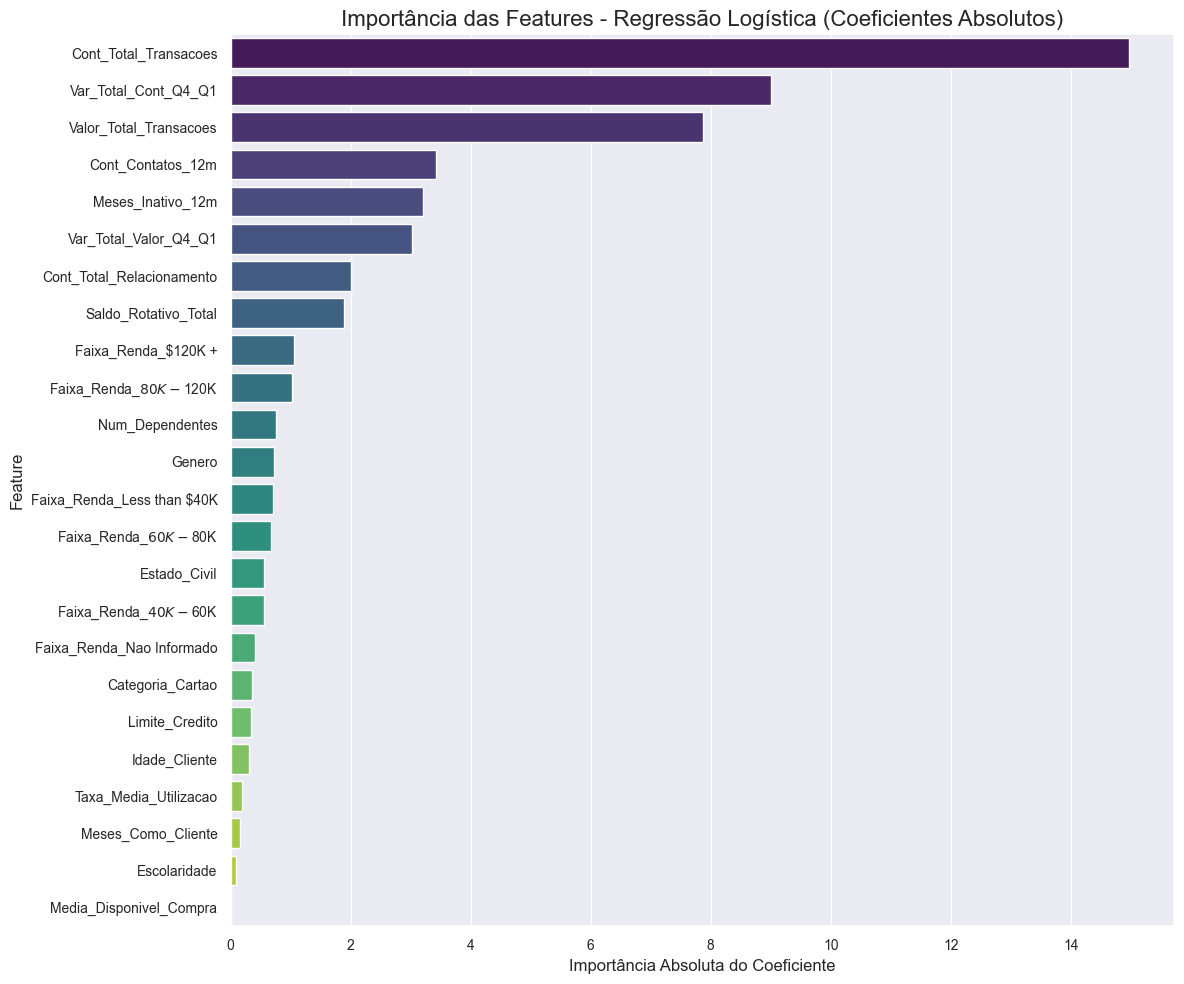


Importância das Features (Regressão Logística):

                       Feature  Coeficiente  Importancia_Absoluta
15       Cont_Total_Transacoes   -14.969881             14.969881
16        Var_Total_Cont_Q4_Q1    -8.999519              8.999519
14      Valor_Total_Transacoes     7.866087              7.866087
9            Cont_Contatos_12m     3.421763              3.421763
8            Meses_Inativo_12m     3.202230              3.202230
13       Var_Total_Valor_Q4_Q1    -3.013844              3.013844
7    Cont_Total_Relacionamento    -2.010300              2.010300
11        Saldo_Rotativo_Total    -1.887464              1.887464
18         Faixa_Renda_$120K +     1.050370              1.050370
21    Faixa_Renda_$80K - $120K     1.029755              1.029755
2              Num_Dependentes     0.750958              0.750958
1                       Genero    -0.718081              0.718081
22  Faixa_Renda_Less than $40K     0.711782              0.711782
20     Faixa_Renda_$60K - 

In [243]:
# TESTE
try:
    # Obter os coeficientes do modelo de Regressão Logística
    # Acessamos o índice [0] porque a Regressão Logística pode ser multinomial,
    # mas no caso binário, temos apenas um conjunto de coeficientes.
    coeficientes_rl = lr_model.coef_[0]

    # Obter os nomes das colunas a partir do X_treino original (antes do scaling)
    nomes_features = X_train_cols

    # Criar um DataFrame para associar features e seus coeficientes
    importancia_rl_df = pd.DataFrame({
        'Feature': nomes_features,
        'Coeficiente': coeficientes_rl
    })

    # Calcular o valor absoluto dos coeficientes para medir a importância
    importancia_rl_df['Importancia_Absoluta'] = np.abs(importancia_rl_df['Coeficiente'])

    # Ordenar o DataFrame pela importância absoluta, do maior para o menor
    importancia_rl_df = importancia_rl_df.sort_values(by='Importancia_Absoluta', ascending=False)

    # Configurar o tamanho do gráfico
    plt.figure(figsize=(12, 10))

    # Criar o gráfico de barras usando Seaborn
    sns.barplot(x='Importancia_Absoluta', y='Feature', data=importancia_rl_df, palette='viridis')

    # Adicionar título e rótulos aos eixos
    plt.title('Importância das Features - Regressão Logística (Coeficientes Absolutos)', fontsize=16)
    plt.xlabel('Importância Absoluta do Coeficiente', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Exibir o gráfico
    plt.tight_layout() # Ajusta o layout para evitar sobreposição
    plt.show()

    # Exibir o DataFrame com as importâncias
    print("\nImportância das Features (Regressão Logística):\n")
    print(importancia_rl_df[['Feature', 'Coeficiente', 'Importancia_Absoluta']].to_string())
except NameError:
    print("Certifique-se de que a variável 'lr_model' e 'X_train' existem e o modelo foi treinado.")



C:\Users\jhona\AppData\Local\Temp\ipykernel_7928\995860133.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=importancia_rf_df, palette='rocket')


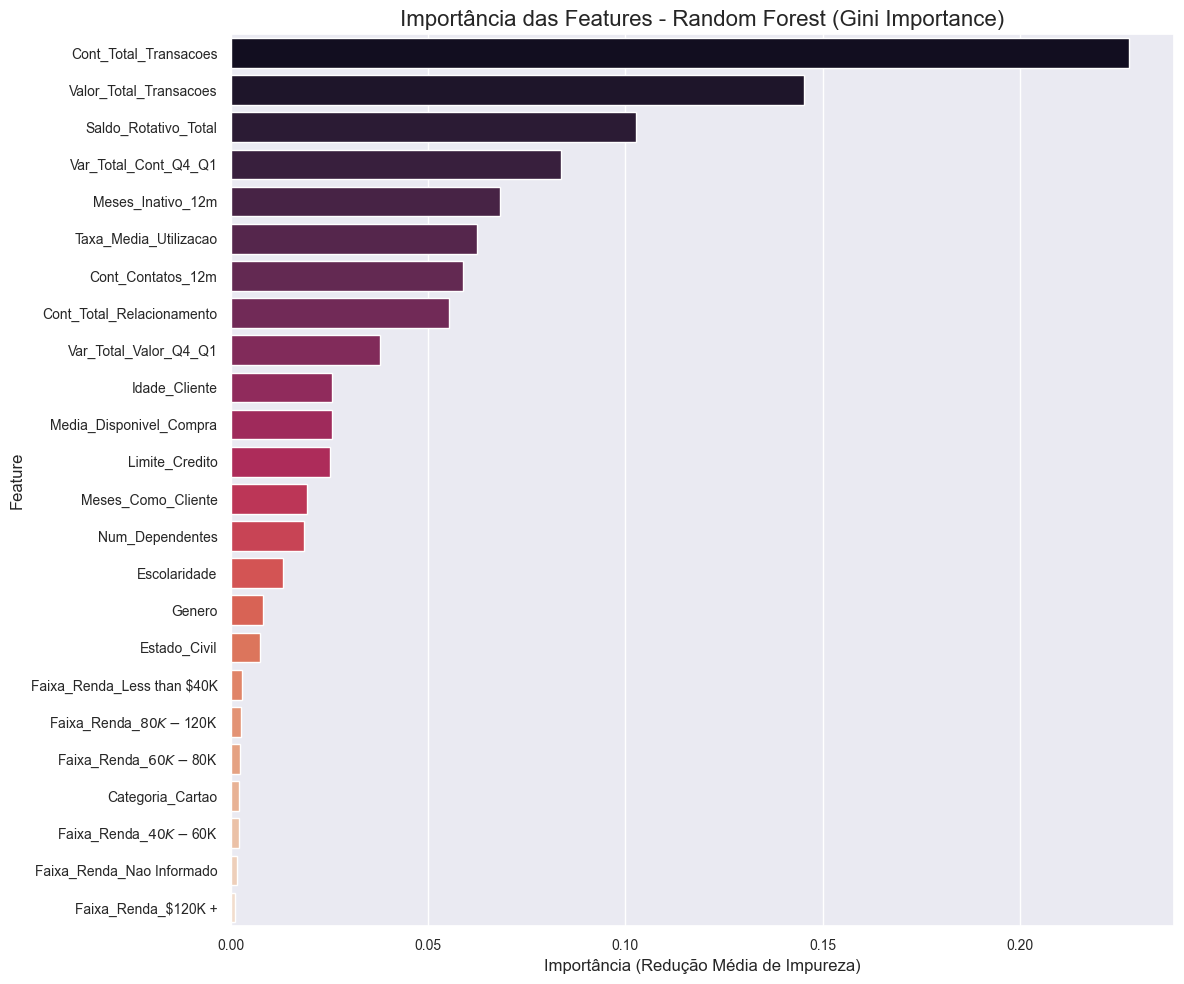


Importância das Features (Random Forest):

                       Feature  Importancia
15       Cont_Total_Transacoes     0.227635
14      Valor_Total_Transacoes     0.145273
11        Saldo_Rotativo_Total     0.102673
16        Var_Total_Cont_Q4_Q1     0.083656
8            Meses_Inativo_12m     0.068358
17       Taxa_Media_Utilizacao     0.062427
9            Cont_Contatos_12m     0.058749
7    Cont_Total_Relacionamento     0.055283
13       Var_Total_Valor_Q4_Q1     0.037819
0                Idade_Cliente     0.025791
12     Media_Disponivel_Compra     0.025683
10              Limite_Credito     0.025182
6           Meses_Como_Cliente     0.019288
2              Num_Dependentes     0.018582
3                 Escolaridade     0.013230
1                       Genero     0.008088
4                 Estado_Civil     0.007334
22  Faixa_Renda_Less than $40K     0.002783
21    Faixa_Renda_$80K - $120K     0.002545
20     Faixa_Renda_$60K - $80K     0.002475
5             Categoria_Cartao  

In [244]:
# Verificar se o modelo_rf está treinado (exemplo)

try:
    # Obter as importâncias das features do modelo Random Forest
    importancias_rf = rf_model_base.feature_importances_

    # Obter os nomes das colunas a partir do X_treino original
    nomes_features = X_train_cols

    # Criar um DataFrame para associar features e suas importâncias
    importancia_rf_df = pd.DataFrame({
        'Feature': nomes_features,
        'Importancia': importancias_rf
    })

    # Ordenar o DataFrame pela importância, do maior para o menor
    importancia_rf_df = importancia_rf_df.sort_values(by='Importancia', ascending=False)

    # Configurar o tamanho do gráfico
    plt.figure(figsize=(12, 10))

    # Criar o gráfico de barras usando Seaborn
    sns.barplot(x='Importancia', y='Feature', data=importancia_rf_df, palette='rocket')

    # Adicionar título e rótulos aos eixos
    plt.title('Importância das Features - Random Forest (Gini Importance)', fontsize=16)
    plt.xlabel('Importância (Redução Média de Impureza)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Exibir o gráfico
    plt.tight_layout()
    plt.show()

    # Exibir o DataFrame com as importâncias
    print("\nImportância das Features (Random Forest):\n")
    print(importancia_rf_df.to_string())

except NameError:
    print("Certifique-se de que a variável 'rf_model_base' e 'X_train' existem e o modelo foi treinado.")

c:\Users\jhona\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


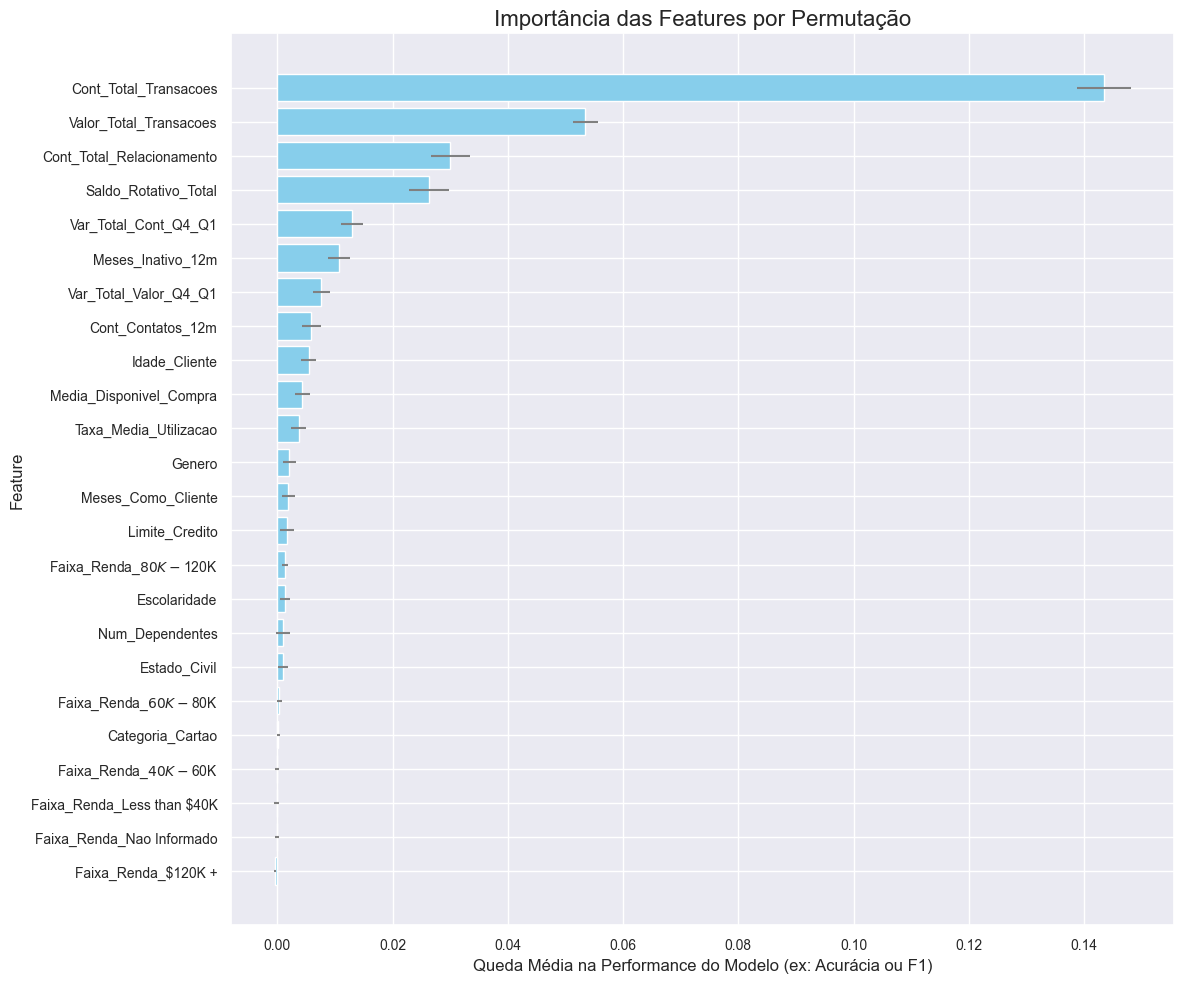


Importância das Features (Permutação):

                       Feature  Importancia_Media  Desvio_Padrao
15       Cont_Total_Transacoes           0.143418       0.004732
14      Valor_Total_Transacoes           0.053449       0.002219
7    Cont_Total_Relacionamento           0.030016       0.003388
11        Saldo_Rotativo_Total           0.026330       0.003387
16        Var_Total_Cont_Q4_Q1           0.013033       0.001897
8            Meses_Inativo_12m           0.010664       0.001880
13       Var_Total_Valor_Q4_Q1           0.007636       0.001503
9            Cont_Contatos_12m           0.005924       0.001599
0                Idade_Cliente           0.005424       0.001277
12     Media_Disponivel_Compra           0.004371       0.001341
17       Taxa_Media_Utilizacao           0.003712       0.001328
1                       Genero           0.002054       0.001128
6           Meses_Como_Cliente           0.001948       0.001167
10              Limite_Credito           0.001711

In [245]:
# Escolha o modelo final para a análise de permutação
# Substitua 'modelo_rf' se o seu modelo final for outro
modelo_para_permutacao = rf_model_base

# Verificar se as variáveis necessárias existem
try:
    # Calcular a importância por permutação
    # Usamos X_teste_scaler e y_teste para avaliar em dados não vistos
    # n_repeats define quantas vezes cada feature é permutada (para robustez)
    resultado_permutacao = permutation_importance(
        modelo_para_permutacao,
        X_test_scaled_array,
        y_test,
        n_repeats=15,       
        random_state=42,    
        n_jobs=-1           
    )

    # Obter os nomes das colunas
    nomes_features = X_train_cols

    # Obter a média e o desvio padrão das importâncias
    importancias_perm_media = resultado_permutacao.importances_mean
    importancias_perm_std = resultado_permutacao.importances_std

    # Criar um DataFrame com os resultados
    importancia_perm_df = pd.DataFrame({
        'Feature': nomes_features,
        'Importancia_Media': importancias_perm_media,
        'Desvio_Padrao': importancias_perm_std
    })

    # Ordenar o DataFrame pela importância média
    importancia_perm_df = importancia_perm_df.sort_values(by='Importancia_Media', ascending=False)

    # Configurar o tamanho do gráfico
    plt.figure(figsize=(12, 10))

    # Criar o gráfico de barras horizontais com barras de erro
    plt.barh(
        importancia_perm_df['Feature'],
        importancia_perm_df['Importancia_Media'],
        xerr=importancia_perm_df['Desvio_Padrao'], # Adiciona barras de erro
        align='center',
        color='skyblue',
        ecolor='gray'
    )

    # Inverter o eixo Y para que a feature mais importante fique no topo
    plt.gca().invert_yaxis()

    # Adicionar título e rótulos
    plt.title('Importância das Features por Permutação', fontsize=16)
    plt.xlabel('Queda Média na Performance do Modelo (ex: Acurácia ou F1)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Exibir o gráfico
    plt.tight_layout()
    plt.show()

    # Exibir o DataFrame com as importâncias
    print("\nImportância das Features (Permutação):\n")
    print(importancia_perm_df.to_string())

except NameError:
    print("Certifique-se de que 'rf_model_base', 'X_train', 'X_test_scaled_array' e 'y_test' existem.")


In [246]:
import joblib

try:
    joblib.dump(rf_tuned, 'Dados_Tratados/modelo_rf_tunado.pkl')
    print('Modelo Criado com Sucesso')
except Exception as erro:
    print(f"\nERRO: Não foi possível salvar o modelo. Detalhes: {erro}")

Modelo Criado com Sucesso


In [247]:
with open('Dados_Tratados/modelo_rf_tunado.pkl', 'rb') as file:
    modelo = joblib.load(file)
    
    print(modelo)

RandomForestClassifier(n_estimators=300, random_state=42)


In [248]:

try:
    importances_do_modelo_rf = rf_tuned.feature_importances_
    print(f"Scores de importância obtidos do modelo 'rf_tuned'. Total: {len(importances_do_modelo_rf)}")
except NameError:
    print("ERRO: A variável 'rf_tuned' (seu modelo Random Forest treinado) não foi encontrada.")
    print("Certifique-se de que o modelo foi treinado e está acessível com este nome.")
    importances_do_modelo_rf = [] # Define como lista vazia para evitar mais erros abaixo
except AttributeError:
    print("ERRO: O objeto 'rf_tuned' não parece ter o atributo 'feature_importances_'.")
    print("Verifique se 'rf_tuned' é um modelo Scikit-learn do tipo árvore treinado (como RandomForestClassifier).")
    importances_do_modelo_rf = []


# 3. Obter os nomes das features
try:
    # Supondo que X_train_resampled foi o DataFrame usado no .fit() do GridSearchCV que gerou rf_tuned
    nomes_das_features = X_train_resampled.columns.tolist()
    print(f"Nomes das features obtidos de X_train_resampled.columns. Total: {len(nomes_das_features)}")
    if len(nomes_das_features) != len(importances_do_modelo_rf) and len(importances_do_modelo_rf) > 0 :
        print(f"ALERTA DE COMPRIMENTO: Nomes das features ({len(nomes_das_features)}) diferente de scores de importância ({len(importances_do_modelo_rf)}).")
        print("Isso pode indicar um problema. Verifique a origem dos nomes das features.")
        # Se houver desalinhamento, você precisará encontrar a fonte correta dos nomes das features.
        # Como fallback extremo, poderia criar nomes genéricos, mas isso perde o significado.
        # nomes_das_features = [f"Feature_{i}" for i in range(len(importances_do_modelo_rf))]

except AttributeError:
    print("Aviso: 'X_train_resampled' não é um DataFrame Pandas ou não tem o atributo '.columns'.")
    if len(importances_do_modelo_rf) > 0:
        print("ERRO CRÍTICO: Não foi possível determinar os nomes das features automaticamente.")
        print("Você precisará definir a lista 'nomes_das_features' manualmente com os nomes corretos das colunas")
        print("que foram usadas para treinar o modelo 'rf_tuned', na ordem correta.")
        nomes_das_features = [f"Feature_Desconhecida_{i}" for i in range(len(importances_do_modelo_rf))] # Placeholder
    else:
        nomes_das_features = []


# 4. Criar um DataFrame Pandas com as features e suas importâncias
#    Só prossiga se os comprimentos forem consistentes e importances_do_modelo_rf não estiver vazio
if len(importances_do_modelo_rf) > 0 and len(nomes_das_features) == len(importances_do_modelo_rf):
    df_importancia_para_sql = pd.DataFrame({
        'Feature': nomes_das_features,
        'Importancia': importances_do_modelo_rf
    })

    # 5. Opcional: Ordenar o DataFrame pela importância (da maior para a menor)
    df_importancia_para_sql = df_importancia_para_sql.sort_values(by='Importancia', ascending=False)

    # 6. Definir o nome do arquivo CSV que será criado
    #nome_arquivo_importancia_csv = 'importancia_features_rf.csv'

    # 7. Salvar o DataFrame em um arquivo CSV
nome_tabela_importancia = 'Importancia_Features_RF'
df_importancia_para_sql.to_sql(
    name=nome_tabela_importancia,
    con=engine,
    if_exists='replace',
    index=False
)
print(f"Tabela de importância de features salva com sucesso na tabela SQL: '{nome_tabela_importancia}'")



Scores de importância obtidos do modelo 'rf_tuned'. Total: 24
Nomes das features obtidos de X_train_resampled.columns. Total: 24
Tabela de importância de features salva com sucesso na tabela SQL: 'Importancia_Features_RF'
